In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rainfall-1901-1999/1915uk.csv
/kaggle/input/rainfall-1901-1999/1971uk.csv
/kaggle/input/rainfall-1901-1999/1914uk.csv
/kaggle/input/rainfall-1901-1999/1986uk.csv
/kaggle/input/rainfall-1901-1999/1977uk.csv
/kaggle/input/rainfall-1901-1999/1939uk.csv
/kaggle/input/rainfall-1901-1999/1949uk.csv
/kaggle/input/rainfall-1901-1999/1973uk.csv
/kaggle/input/rainfall-1901-1999/1945uk.csv
/kaggle/input/rainfall-1901-1999/1966uk.csv
/kaggle/input/rainfall-1901-1999/1946uk.csv
/kaggle/input/rainfall-1901-1999/1908uk.csv
/kaggle/input/rainfall-1901-1999/1941UK.csv
/kaggle/input/rainfall-1901-1999/1940uk.csv
/kaggle/input/rainfall-1901-1999/1924uk.csv
/kaggle/input/rainfall-1901-1999/1921uk.csv
/kaggle/input/rainfall-1901-1999/1984uk.csv
/kaggle/input/rainfall-1901-1999/1926uk.csv
/kaggle/input/rainfall-1901-1999/1962uk.csv
/kaggle/input/rainfall-1901-1999/1987uk.csv
/kaggle/input/rainfall-1901-1999/1931uk.csv
/kaggle/input/rainfall-1901-1999/1905uk.csv
/kaggle/input/rainfall-1901-1999

In [3]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv("/kaggle/input/rainfall-1901-1999/1957uk.csv")

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Replace all NaNs with 0 (or another value if needed)
df.fillna(0, inplace=True)

# Optionally ensure all Day_x columns are numeric
day_cols = [col for col in df.columns if col.startswith("Day_")]
df[day_cols] = df[day_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Check the result
print(df.describe())
print(df.columns)



             FID      Day_1      Day_2      Day_3      Day_4  Day_5  \
count  83.000000  83.000000  83.000000  83.000000  83.000000   83.0   
mean   41.000000   0.301205  10.915663   7.759036   1.277108    0.0   
std    24.103942   1.904647  10.951339  12.198151   2.683796    0.0   
min     0.000000   0.000000   0.000000   0.000000   0.000000    0.0   
25%    20.500000   0.000000   3.000000   1.000000   0.000000    0.0   
50%    41.000000   0.000000   7.000000   2.000000   0.000000    0.0   
75%    61.500000   0.000000  17.500000   7.000000   0.500000    0.0   
max    82.000000  17.000000  48.000000  55.000000  12.000000    0.0   

           Day_6      Day_7      Day_8      Day_9  ...  Day_357  Day_358  \
count  83.000000  83.000000  83.000000  83.000000  ...     83.0     83.0   
mean    4.602410   5.469880  12.530120  26.927711  ...      0.0      0.0   
std     9.832673  10.358615   8.021826  12.379944  ...      0.0      0.0   
min     0.000000   0.000000   1.000000   1.000000  ...  

In [4]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Step 1: Create DataFrame from provided list
data = [
    (0, 28.75, 80), (1, 29, 79.25), (2, 29, 79.5), (3, 29, 79.75), (4, 29, 80),
    (5, 29.25, 79), (6, 29.25, 79.25), (7, 29.25, 79.5), (8, 29.25, 79.75), (9, 29.25, 80),
    (10, 29.25, 80.25), (11, 29.5, 78.75), (12, 29.5, 79), (13, 29.5, 79.25), (14, 29.5, 79.5),
    (15, 29.5, 79.75), (16, 29.5, 80), (17, 29.5, 80.25), (18, 29.75, 78), (19, 29.75, 78.25),
    (20, 29.75, 78.5), (21, 29.75, 78.75), (22, 29.75, 79), (23, 29.75, 79.25), (24, 29.75, 79.5),
    (25, 29.75, 79.75), (26, 29.75, 80), (27, 29.75, 80.25), (28, 30, 77.75), (29, 30, 78),
    (30, 30, 78.25), (31, 30, 78.5), (32, 30, 78.75), (33, 30, 79), (34, 30, 79.25),
    (35, 30, 79.5), (36, 30, 79.75), (37, 30, 80), (38, 30, 80.25), (39, 30, 80.5),
    (40, 30.25, 78), (41, 30.25, 78.25), (42, 30.25, 78.5), (43, 30.25, 78.75), (44, 30.25, 79),
    (45, 30.25, 79.25), (46, 30.25, 79.5), (47, 30.25, 79.75), (48, 30.25, 80), (49, 30.25, 80.25),
    (50, 30.25, 80.5), (51, 30.25, 80.75), (52, 30.25, 81), (53, 30.5, 78), (54, 30.5, 78.25),
    (55, 30.5, 78.5), (56, 30.5, 78.75), (57, 30.5, 79), (58, 30.5, 79.25), (59, 30.5, 79.5),
    (60, 30.5, 79.75), (61, 30.5, 80), (62, 30.5, 80.25), (63, 30.75, 77.75), (64, 30.75, 78),
    (65, 30.75, 78.25), (66, 30.75, 78.5), (67, 30.75, 78.75), (68, 30.75, 79), (69, 30.75, 79.25),
    (70, 30.75, 79.5), (71, 30.75, 79.75), (72, 30.75, 80), (73, 31, 78), (74, 31, 78.25),
    (75, 31, 78.5), (76, 31, 78.75), (77, 31, 79), (78, 31, 79.25), (79, 31, 79.5), (80, 31, 79.75),
    (81, 31.25, 78.25), (82, 31.25, 79)
]

df_map = pd.DataFrame(data, columns=['FID', 'Lat', 'Long'])

# Step 2: Convert to GeoDataFrame
df_map['geometry'] = df_map.apply(lambda row: Point(row['Long'], row['Lat']), axis=1)
points = gpd.GeoDataFrame(df_map, geometry='geometry', crs="EPSG:4326")

# Step 3: Load India district boundaries
districts = gpd.read_file("/kaggle/input/india-district-data/india_district.geojson")  # Replace with your actual file path
districts = districts.to_crs("EPSG:4326")
print(districts.columns)


# Step 4: Spatial join to find district for each point
joined = gpd.sjoin(points, districts, how="left", predicate='within')

# Step 5: Display relevant info
# print(joined[['FID', 'Lat', 'Long', 'DISTRICT_NAME_COLUMN']])  # replace with actual district column
print(joined[['FID', 'Lat', 'Long', 'NAME_2']])


Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'ID_2', 'NAME_2',
       'NL_NAME_2', 'VARNAME_2', 'TYPE_2', 'ENGTYPE_2', 'geometry'],
      dtype='object')
    FID    Lat   Long             NAME_2
0     0  28.75  80.00  Udham Singh Nagar
1     1  29.00  79.25  Udham Singh Nagar
2     2  29.00  79.50  Udham Singh Nagar
3     3  29.00  79.75  Udham Singh Nagar
4     4  29.00  80.00  Udham Singh Nagar
..  ...    ...    ...                ...
78   78  31.00  79.25         Uttarkashi
79   79  31.00  79.50            Chamoli
80   80  31.00  79.75            Chamoli
81   81  31.25  78.25         Uttarkashi
82   82  31.25  79.00         Uttarkashi

[83 rows x 4 columns]


In [4]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Step 1: Create DataFrame from provided list
data = [
    (0, 28.75, 80), (1, 29, 79.25), (2, 29, 79.5), (3, 29, 79.75), (4, 29, 80),
    (5, 29.25, 79), (6, 29.25, 79.25), (7, 29.25, 79.5), (8, 29.25, 79.75), (9, 29.25, 80),
    (10, 29.25, 80.25), (11, 29.5, 78.75), (12, 29.5, 79), (13, 29.5, 79.25), (14, 29.5, 79.5),
    (15, 29.5, 79.75), (16, 29.5, 80), (17, 29.5, 80.25), (18, 29.75, 78), (19, 29.75, 78.25),
    (20, 29.75, 78.5), (21, 29.75, 78.75), (22, 29.75, 79), (23, 29.75, 79.25), (24, 29.75, 79.5),
    (25, 29.75, 79.75), (26, 29.75, 80), (27, 29.75, 80.25), (28, 30, 77.75), (29, 30, 78),
    (30, 30, 78.25), (31, 30, 78.5), (32, 30, 78.75), (33, 30, 79), (34, 30, 79.25),
    (35, 30, 79.5), (36, 30, 79.75), (37, 30, 80), (38, 30, 80.25), (39, 30, 80.5),
    (40, 30.25, 78), (41, 30.25, 78.25), (42, 30.25, 78.5), (43, 30.25, 78.75), (44, 30.25, 79),
    (45, 30.25, 79.25), (46, 30.25, 79.5), (47, 30.25, 79.75), (48, 30.25, 80), (49, 30.25, 80.25),
    (50, 30.25, 80.5), (51, 30.25, 80.75), (52, 30.25, 81), (53, 30.5, 78), (54, 30.5, 78.25),
    (55, 30.5, 78.5), (56, 30.5, 78.75), (57, 30.5, 79), (58, 30.5, 79.25), (59, 30.5, 79.5),
    (60, 30.5, 79.75), (61, 30.5, 80), (62, 30.5, 80.25), (63, 30.75, 77.75), (64, 30.75, 78),
    (65, 30.75, 78.25), (66, 30.75, 78.5), (67, 30.75, 78.75), (68, 30.75, 79), (69, 30.75, 79.25),
    (70, 30.75, 79.5), (71, 30.75, 79.75), (72, 30.75, 80), (73, 31, 78), (74, 31, 78.25),
    (75, 31, 78.5), (76, 31, 78.75), (77, 31, 79), (78, 31, 79.25), (79, 31, 79.5), (80, 31, 79.75),
    (81, 31.25, 78.25), (82, 31.25, 79)
]

df_map = pd.DataFrame(data, columns=['FID', 'Lat', 'Long'])

# Step 2: Convert to GeoDataFrame
df_map['geometry'] = df_map.apply(lambda row: Point(row['Long'], row['Lat']), axis=1)
points = gpd.GeoDataFrame(df_map, geometry='geometry', crs="EPSG:4326")

# Step 3: Load India district boundaries
districts = gpd.read_file("/kaggle/input/india-district-data/india_district.geojson")  # Replace with your actual file path
districts = districts.to_crs("EPSG:4326")
print(districts.columns)


# Step 4: Spatial join to find district for each point
joined = gpd.sjoin(points, districts, how="left", predicate='within')

# Step 5: Display relevant info
# print(joined[['FID', 'Lat', 'Long', 'DISTRICT_NAME_COLUMN']])  # replace with actual district column
print(joined[['FID', 'Lat', 'Long', 'NAME_2']])


Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'ID_2', 'NAME_2',
       'NL_NAME_2', 'VARNAME_2', 'TYPE_2', 'ENGTYPE_2', 'geometry'],
      dtype='object')
    FID    Lat   Long             NAME_2
0     0  28.75  80.00  Udham Singh Nagar
1     1  29.00  79.25  Udham Singh Nagar
2     2  29.00  79.50  Udham Singh Nagar
3     3  29.00  79.75  Udham Singh Nagar
4     4  29.00  80.00  Udham Singh Nagar
..  ...    ...    ...                ...
78   78  31.00  79.25         Uttarkashi
79   79  31.00  79.50            Chamoli
80   80  31.00  79.75            Chamoli
81   81  31.25  78.25         Uttarkashi
82   82  31.25  79.00         Uttarkashi

[83 rows x 4 columns]


/tmp/ipykernel_31/1068652554.py:1428: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Blues')


ValueError: aspect must be finite and positive 

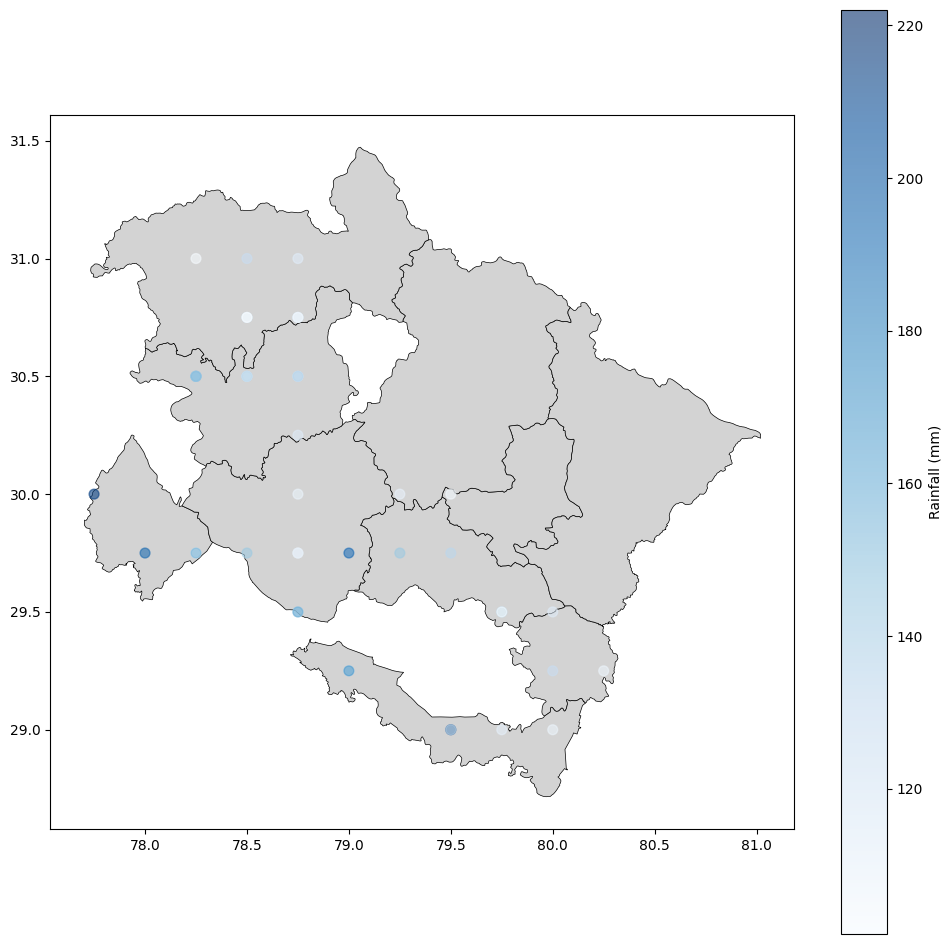

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from datetime import datetime


landslide_data = [
    {
        "Date": "September 18, 1948",
        "Places": "Guwahati, Assam",
        "Mortality and Dimension": "500 people died, buried an entire village",
        "Latitude": "26°08’35.71\" N",
        "Longitude": "91°44’10.45\" E"
    },
    {
        "Date": "July, 1968",
        "Places": "Garhwal Himalaya",
        "Mortality and Dimension": "damage to road",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 4, 1968",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "Thousand people died, 60KM long highway cut in 91 parts",
        "Latitude": "27°02’9.62\" N",
        "Longitude": "88°15’45.03\" E"
    },
    {
        "Date": "January, 1982",
        "Places": "Nashri, Jammu & Kashmir",
        "Mortality and Dimension": "road and communication network is damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 1968",
        "Places": "Maling, H.P",
        "Mortality and Dimension": "damaged 1 Km NH-22",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "Dec, 1982",
        "Places": "Kinnaur, H.P",
        "Mortality and Dimension": "occurred at Sholding nala collapsing 3 bridges and 1.5 of road was vanished",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March, 1989",
        "Places": "Jhakri, H.P",
        "Mortality and Dimension": "about 500 m of road was damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October, 1990",
        "Places": "Kundah, Nilgiris",
        "Mortality and Dimension": "36 people killed, several building were damaged",
        "Latitude": "11°15’40.41\" N",
        "Longitude": "76°38’15.95\" E"
    },
    {
        "Date": "July, 1991",
        "Places": "Guwahati, Assam",
        "Mortality and Dimension": "300 people were killed, roads and buildings were damaged",
        "Latitude": "26°12’02.18\" N",
        "Longitude": "92°56’15.27\" E"
    },
    {
        "Date": "1991",
        "Places": "Uttarkashi, U.P.",
        "Mortality and Dimension": "More than 2000 lives lost, houses and bridges damaged",
        "Latitude": "30°43’36.59\" N",
        "Longitude": "78°26’7.46\" E"
    },
    {
        "Date": "1992",
        "Places": "Mizoram",
        "Mortality and Dimension": "Extensive damage to roads in the region",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November, 1992",
        "Places": "Kundah, Nilgiris",
        "Mortality and Dimension": "Road network damaged & loss of property over Rs. 5 millions",
        "Latitude": "11°15’40.41\" N",
        "Longitude": "76°38’15.95\" E"
    },
    {
        "Date": "Feb 25, 1993",
        "Places": "Kinnaur, H.P",
        "Mortality and Dimension": "affected the highway, NH-22 (450m), blocking for two months",
        "Latitude": "31°39’3.45\" N",
        "Longitude": "78°28’31.71\" E"
    },
    {
        "Date": "May 10, 1993",
        "Places": "Kaki Khola, Sonpur Division, Tripura",
        "Mortality and Dimension": "collapse of house, 6 person buried alive, and a few injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 3, 1993",
        "Places": "Mizoram",
        "Mortality and Dimension": "Three killed and several injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 9, 1993",
        "Places": "Thiruvanantapuram",
        "Mortality and Dimension": "8 killed and property damaged",
        "Latitude": "8°31’26.63\" N",
        "Longitude": "76°56’37.96\" E"
    },
    {
        "Date": "June 20, 1993",
        "Places": "China Chip Village, Aizwal",
        "Mortality and Dimension": "Five killed in landslides",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "July, 1993",
        "Places": "Aizawl",
        "Mortality and Dimension": "4 persons buried",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "July 1, 1993",
        "Places": "Itanagar, Arunachal Pradesh",
        "Mortality and Dimension": "25 people were buried alive",
        "Latitude": "27°05’3.73\" N",
        "Longitude": "93°36’19.14\" E"
    },
    {
        "Date": "August 5, 1993",
        "Places": "Kalimpong, West Bengal",
        "Mortality and Dimension": "40 people were killed, heavy loss of property",
        "Latitude": "27°03’33.68\" N",
        "Longitude": "88°28’10.03\" E"
    },
    {
        "Date": "August 21, 1993",
        "Places": "Urni, H.P.",
        "Mortality and Dimension": "A jeep with its occupants was buried on H.T. road, 40 km from Shimla",
        "Latitude": "31°31’57.99\" N",
        "Longitude": "78°07’46.89\" E"
    },
    {
        "Date": "August 17, 1993",
        "Places": "Kohima, Nagaland",
        "Mortality and Dimension": "200 houses destroyed, 500 people died, 5 km road was damaged",
        "Latitude": "26°09’30.37\" N",
        "Longitude": "94°33’44.79\" E"
    },
    {
        "Date": "September 12, 1993",
        "Places": "Ratighat, U.P.",
        "Mortality and Dimension": "Nainital Hill area remained cutoff for about a week",
        "Latitude": "29°22’43.15\" N",
        "Longitude": "79°27’94.81\" E"
    },
    {
        "Date": "November, 1993",
        "Places": "Nilgiri, Tamil Nadu",
        "Mortality and Dimension": "408 Landslides occurred, Marapplam killed 40 people and destroyed property",
        "Latitude": "11°29’22.44\" N",
        "Longitude": "76°44’26.44\" E"
    },
    {
        "Date": "1993",
        "Places": "Jammu and Kashmir",
        "Mortality and Dimension": "Road Blockage",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "Jan-94",
        "Places": "Kashmir",
        "Mortality and Dimension": "National Highway 1A severely damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 1994",
        "Places": "Varundh ghat, Konkan Coast",
        "Mortality and Dimension": "20 people were killed, 1km of road was damaged",
        "Latitude": "18°58’31.46\" N",
        "Longitude": "72°54’45.92\" E"
    },
    {
        "Date": "May, 1995",
        "Places": "Aizawl, Mizoram",
        "Mortality and Dimension": "25 people killed, road damaged",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "June, 1995",
        "Places": "Malari, J&K",
        "Mortality and Dimension": "6 persons killed. NH 1A damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 12, 1995",
        "Places": "Luggarbhati, H.P",
        "Mortality and Dimension": "39 were buried alive",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 1995",
        "Places": "Kullu, H.P.",
        "Mortality and Dimension": "22 persons killed, 1km road damaged",
        "Latitude": "31°57’28.26\" N",
        "Longitude": "77°06’31.05\" E"
    },
    {
        "Date": "July 11-12, 1996",
        "Places": "Jaldhaka valley and South Kalimpong hills",
        "Mortality and Dimension": "32 lives lost, damages to huge property",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 9, 1997",
        "Places": "Gangtok",
        "Mortality and Dimension": "Widespread devastation of Gangtok town",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 14, 1998",
        "Places": "Okhimath, Uttarakhand",
        "Mortality and Dimension": "69 people were killed",
        "Latitude": "30°30’53.57\" N",
        "Longitude": "79°05’45.47\" E"
    },
    {
        "Date": "August 18, 1998",
        "Places": "Malpa, Uttaranchal",
        "Mortality and Dimension": "200 people perished",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 7, 1999",
        "Places": "Kurseong town",
        "Mortality and Dimension": "Kurseong town devastated",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 12, 2000",
        "Places": "Mumbai, Maharashtra",
        "Mortality and Dimension": "67 people were killed",
        "Latitude": "19°04’33.54\" N",
        "Longitude": "72°52’39.56\" E"
    },
    {
        "Date": "November 9, 2001",
        "Places": "Amboori, Kerala",
        "Mortality and Dimension": "39 people were killed",
        "Latitude": "8°30’14.84\" N",
        "Longitude": "77°11’29.94\" E"
    },
    {
        "Date": "Sept 23, 2003",
        "Places": "Varunavat parvat, Uttarkashi",
        "Mortality and Dimension": "led to the blockage of the pilgrim route to Gangotri",
        "Latitude": "30°43’36.71\" N",
        "Longitude": "78°26’09.67\" E"
    },
    {
        "Date": "September, 2004",
        "Places": "Uttarkashi, Uttrakhand",
        "Mortality and Dimension": "3 four storeyed hotel building buried completely and NH 72 blocked for several days, posed risk to of about 200 houses at footslopes",
        "Latitude": "30°43’36.71\" N",
        "Longitude": "78°26’09.67\" E"
    },
    {
        "Date": "July 5, 2004",
        "Places": "Badrinath, Chamoli, Uttarakhand",
        "Mortality and Dimension": "16 persons killed, 200 pilgrims stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2005",
        "Places": "Raigad",
        "Mortality and Dimension": "54 people were killed",
        "Latitude": "18°30’56.71\" N",
        "Longitude": "73°10’55.78\" E"
    },
    {
        "Date": "July 26, 2005",
        "Places": "Sakinaka, Mumbai",
        "Mortality and Dimension": "74 people were killed",
        "Latitude": "19°05’41.62\" N",
        "Longitude": "72°53’11.49\" E"
    },
    {
        "Date": "August, 2005",
        "Places": "Mumbai",
        "Mortality and Dimension": "Buildings collapsed and people buried",
        "Latitude": "19°05’41.62\" N",
        "Longitude": "72°53’11.49\" E"
    },
    {
        "Date": "October 8, 2005",
        "Places": "Kashmir",
        "Mortality and Dimension": "1000 fatalities, destroying roads, and disrupting communications",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2006",
        "Places": "Mangalore, Karnataka",
        "Mortality and Dimension": "Several Building at risk due to landslide",
        "Latitude": "12°54’50.91\" N",
        "Longitude": "74°51’21.44\" E"
    },
    {
        "Date": "August 14, 2007",
        "Places": "Dharla village, H.P",
        "Mortality and Dimension": "Burial of entire village",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 15, 2007",
        "Places": "Ladakh",
        "Mortality and Dimension": "6 injured, 2 died",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 17, 2009",
        "Places": "Brari marg on the Baltat route, J&K",
        "Mortality and Dimension": "1 killed, 4 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 30, 2009",
        "Places": "Adoshi tunnel at Khandala ghat, on the Pune-Mumbai expressway",
        "Mortality and Dimension": "1 killed, 5 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 21, 2009",
        "Places": "Syara, Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "Three members of a family were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2009",
        "Places": "Gopeshwar, Chamoli, Uttarakhand",
        "Mortality and Dimension": "two labourers were killed and 4 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2009",
        "Places": "Jumma on Joshimath Malari road",
        "Mortality and Dimension": "three persons of a family",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 27, 2009",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "Balipara-Tawang Road to Sino-India border was cut off",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 1, 2009",
        "Places": "Kyongsala, Sikkim",
        "Mortality and Dimension": "claimed the life of a Border Roads Organisation (BRO) labourer",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 29, 2009",
        "Places": "Vaishnodevi, Reasi, J&K",
        "Mortality and Dimension": "a woman pilgrim was killed and two others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 2, 2009",
        "Places": "Rangrik, Lahaul and Spiti, H.P",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 7, 2009",
        "Places": "Kumarda, H.P",
        "Mortality and Dimension": "destroyed three houses, three cowsheds, and washed away 10 animals and a private bus",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 8, 2009",
        "Places": "Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "Three villages viz. Chachna, Lah and Rumiadola were swept away",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 16, 2009",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "leading to blockade of main road link (NH55) between Siliguri and Darjeeling",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 16, 2009",
        "Places": "Dunali, Bharmor to Dharmashala",
        "Mortality and Dimension": "death of one person and has seriously injured seven others",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 17, 2009",
        "Places": "Champawat, Uttarakhand",
        "Mortality and Dimension": "two persons were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 20, 2009",
        "Places": "Jorabat and Sonapur, Assam",
        "Mortality and Dimension": "NH-37 was blocked",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 20, 2009",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "three persons were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 28, 2009",
        "Places": "Munsiari Tehsi, Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "a person was killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 28, 2009",
        "Places": "North Cachar Hills district, Assam",
        "Mortality and Dimension": "train services were disrupted on the 184-km metre gauge track from Lumding to Badarpur",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 2, 2009",
        "Places": "Chinona, Almora, Uttarakhand",
        "Mortality and Dimension": "three people were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 3, 2009",
        "Places": "Andheri, Mumbai",
        "Mortality and Dimension": "12 people were killed and 13 others injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 5, 2009",
        "Places": "Gorshila, Uttarakhand",
        "Mortality and Dimension": "led to the traffic disruption for seven hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 8, 2009",
        "Places": "Uttarakhand",
        "Mortality and Dimension": "three persons were killed and five others injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 2, 2009",
        "Places": "Canacona, Goa",
        "Mortality and Dimension": "the services on Konkan railway route were severely affected",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 2, 2009",
        "Places": "Madibagh, Uttara Kannada",
        "Mortality and Dimension": "24 people were buried alive when nine houses collapsed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 3, 2009",
        "Places": "Kozhikode, Kerala",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 6, 2009",
        "Places": "Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "a big group of tourists was stranded due to blocking of highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 26, 2009",
        "Places": "Belthangady taluk, Karnataka",
        "Mortality and Dimension": "a construction worker was killed and two others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 8, 2009",
        "Places": "Manthada, Nilgiri",
        "Mortality and Dimension": "five members of a family were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 10, 2009",
        "Places": "Ooty, Tamilnadu",
        "Mortality and Dimension": "killing at least 39 people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 16, 2009",
        "Places": "Chamba-Jot road, Himachal Pradesh",
        "Mortality and Dimension": "The road was closed for traffic for about four hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 12, 2009",
        "Places": "Nag Post, Keran Sector, Kupwara, J&K",
        "Mortality and Dimension": "A BSF porter was feared killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "January 3, 2010",
        "Places": "Vaishnodevi in Trikuta hills of Reasi district, Jammu & Kashmir",
        "Mortality and Dimension": "left a pilgrim injured",
        "Latitude": "33.0308° N",
        "Longitude": "74.9490° E"
    },
    {
        "Date": "February 8-9, 2010",
        "Places": "Kalath on the Manali-Kullu highway (on NH-22)",
        "Mortality and Dimension": "Both the road stretches from Kullu - one from the Naggar side and the second the main national highway were blocked at various points",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 8, 2010",
        "Places": "Narundi area of Uri, Baramulla",
        "Mortality and Dimension": "1 person was killed and 6 others were injured",
        "Latitude": "34.0881° N",
        "Longitude": "74.0340° E"
    },
    {
        "Date": "February 14, 2010",
        "Places": "Kachsthal village, Kinnaur",
        "Mortality and Dimension": "6 persons were killed and 14 others injured",
        "Latitude": "31°39’3.45\" N",
        "Longitude": "78°28’31.71\" E"
    },
    {
        "Date": "February 22, 2010",
        "Places": "Chairvani Village, Ganderbal, J & K",
        "Mortality and Dimension": "1 person was killed and 6 injured",
        "Latitude": "34.2165° N",
        "Longitude": "74.7719° E"
    },
    {
        "Date": "February 23, 2010",
        "Places": "Tangadia, Tehri, Uttarakhand",
        "Mortality and Dimension": "2 children were killed and another injured",
        "Latitude": "30.3012° N",
        "Longitude": "78.5661° E"
    },
    {
        "Date": "February 25, 2010",
        "Places": "Granite quarry, Ongole, Prakasam, Andhra Pradesh",
        "Mortality and Dimension": "about 20 workers were feared killed",
        "Latitude": "15.5057° N",
        "Longitude": "80.0499° E"
    },
    {
        "Date": "February 27, 2010",
        "Places": "Vaishno Devi, Katra, J&K",
        "Mortality and Dimension": "2 pilgrims died",
        "Latitude": "33.0308° N",
        "Longitude": "74.9490° E"
    },
    {
        "Date": "March 27, 2010",
        "Places": "LangthAbal Khoupum, Imphal, Manipur",
        "Mortality and Dimension": "1 house was completely damaged",
        "Latitude": "24.8170° N",
        "Longitude": "93.9368° E"
    },
    {
        "Date": "April 2, 2010",
        "Places": "Koloriang, Kurung Kumey, Arunachal Pradesh",
        "Mortality and Dimension": "7 people were killed",
        "Latitude": "27.900° N",
        "Longitude": "93.350° E"
    },
    {
        "Date": "April 20, 2010",
        "Places": "Srinagar-Ladakh highway",
        "Mortality and Dimension": "The highway was closed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 21, 2010",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "12 people have died",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 12, 2010",
        "Places": "Jaintia Hills, Meghalaya",
        "Mortality and Dimension": "disrupted the traffic to Tripura, Mizoram and southern Assam",
        "Latitude": "25°30’07.66\" N",
        "Longitude": "92°20’30.79\" E"
    },
    {
        "Date": "May 18, 2010",
        "Places": "Chang La top, Jammu and Kashmir",
        "Mortality and Dimension": "2 persons were killed, 73 other persons trapped",
        "Latitude": "34.0472° N",
        "Longitude": "77.9305° E"
    },
    {
        "Date": "May 20, 2010",
        "Places": "Vijaywada, Andhra Pradesh",
        "Mortality and Dimension": "4 people were killed",
        "Latitude": "16.5062° N",
        "Longitude": "80.6480° E"
    },
    {
        "Date": "May 25, 2010",
        "Places": "Chadiyan village, Uri, J&K",
        "Mortality and Dimension": "damaged several houses",
        "Latitude": "34.0881° N",
        "Longitude": "74.0340° E"
    },
    {
        "Date": "June 3, 2010",
        "Places": "Rongpur, Karimganj, Assam",
        "Mortality and Dimension": "2 persons dead and 5 others injured",
        "Latitude": "24.6005° N",
        "Longitude": "92.3814° E"
    },
    {
        "Date": "June 8, 2010",
        "Places": "Irang, Manipur",
        "Mortality and Dimension": "suspended traffic along the highway (NH53)",
        "Latitude": "24.76383° N",
        "Longitude": "93.85573° E"
    },
    {
        "Date": "June 9, 2010",
        "Places": "Shimla, Himachal Pradesh",
        "Mortality and Dimension": "resulted in road blocks",
        "Latitude": "31.1048° N",
        "Longitude": "77.1734° E"
    },
    {
        "Date": "June 9, 2010",
        "Places": "Kempty falls, Mussoorie, Uttarakhand",
        "Mortality and Dimension": "damaged 4 vehicles including a bus",
        "Latitude": "30.4873° N",
        "Longitude": "78.0363° E"
    },
    {
        "Date": "June 16, 2010",
        "Places": "Kalimpong, Darjeeling",
        "Mortality and Dimension": "3 people died and 2 others injured",
        "Latitude": "27.0594° N",
        "Longitude": "88.4695° E"
    },
    {
        "Date": "June 16, 2010",
        "Places": "Wadringdisa, North Cachar Hills, Assam",
        "Mortality and Dimension": "disrupted train services",
        "Latitude": "25.3478004° N",
        "Longitude": "93.0175712° E"
    },
    {
        "Date": "June 19, 2010",
        "Places": "Harnai, Ratnagiri, Maharashtra",
        "Mortality and Dimension": "buried 2 houses killing 8 persons",
        "Latitude": "17.8032698° N",
        "Longitude": "73.102383° E"
    },
    {
        "Date": "June 28, 2010",
        "Places": "Shillong, Meghalaya",
        "Mortality and Dimension": "girl was killed and at least 7 others were injured",
        "Latitude": "25.5788° N",
        "Longitude": "91.8933° E"
    },
    {
        "Date": "July 3, 2010",
        "Places": "National Highway 55, West Bengal",
        "Mortality and Dimension": "led to the suspension of the services of Darjeeling Himalayan Railway (DHR)",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 11, 2010",
        "Places": "Rani nullah, H.P",
        "Mortality and Dimension": "The traffic to Manali-Keylong and Leh and Pangi, Kaza and Spiti came to a standstill",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 14, 2010",
        "Places": "Tingda, North Sikkim",
        "Mortality and Dimension": "blocked the Mangan-Gangtok Highway",
        "Latitude": "27.3965° N",
        "Longitude": "88.6368° E"
    },
    {
        "Date": "July 22, 2011",
        "Places": "Patlot-Aghora road, Almora",
        "Mortality and Dimension": "led to the death of 1 person",
        "Latitude": "29.8150° N",
        "Longitude": "79.2902° E"
    },
    {
        "Date": "July 25, 2010",
        "Places": "Panthal, J&K",
        "Mortality and Dimension": "blocked the Jammu-Srinagar highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 25, 2010",
        "Places": "Kanlog, Shimla",
        "Mortality and Dimension": "2 labourers lost their lives and 3 people were injured",
        "Latitude": "31.1048° N",
        "Longitude": "77.1734° E"
    },
    {
        "Date": "July 28, 2010",
        "Places": "Maram, Manipur",
        "Mortality and Dimension": "has cut off the Imphal-Mao section of the NH-39",
        "Latitude": "25.4236° N",
        "Longitude": "94.1066° E"
    },
    {
        "Date": "July 29, 2010",
        "Places": "NH 53, Tupul, Tamenglong, Manipur",
        "Mortality and Dimension": "disturbed the connection of Manipur with Silchar",
        "Latitude": "24.9582° N",
        "Longitude": "93.5003° E"
    },
    {
        "Date": "July 29, 2010",
        "Places": "Shakthinagar, Mangalore",
        "Mortality and Dimension": "damaged a house and injured 1 person",
        "Latitude": "12.9022° N",
        "Longitude": "74.8785° E"
    },
    {
        "Date": "July 31, 2010",
        "Places": "NH-22 near Taradevi, H.P",
        "Mortality and Dimension": "disrupted traffic on the highway",
        "Latitude": "31.0689° N",
        "Longitude": "77.1341° E"
    },
    {
        "Date": "August 5, 2010",
        "Places": "Basantpur, Chamoli, Uttarakhand",
        "Mortality and Dimension": "A house collapsed in the landslides killing five members of a family",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 6, 2010",
        "Places": "Ladakh, Leh",
        "Mortality and Dimension": "255 people were killed, 71 towns and village were damaged",
        "Latitude": "34°09’41.91\" N",
        "Longitude": "77°35’1.36\" E"
    },
    {
        "Date": "August 19, 2010",
        "Places": "Kapkot, Bageshwar, Uttarakhand",
        "Mortality and Dimension": "18 little children died and nearly 30 more trapped under the rubble of a school building",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 12, 2010",
        "Places": "Panchkula-Morni route, Haryana",
        "Mortality and Dimension": "around 150 people on way stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 19, 2010",
        "Places": "Garhwal and Kumaon, Uttarakhand",
        "Mortality and Dimension": "37 people were killed, around 5,000 tourists were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 23, 2010",
        "Places": "Uri, J&K",
        "Mortality and Dimension": "hampered traffic movement to Ladakh",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 27, 2010",
        "Places": "Sikkim",
        "Mortality and Dimension": "7 landslides struck a 15km stretch of NH31A and crippled traffic on Sikkim’s only road link",
        "Latitude": "27°20’13.36\" N",
        "Longitude": "88°36’51.00\" E"
    },
    {
        "Date": "February 14, 2011",
        "Places": "Ramban District, J&K",
        "Mortality and Dimension": "resulted in stranding of over 1200 vehicles on the Jammu-Srinagar National Highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 26 - March 5, 2011",
        "Places": "Kullu, H.P.",
        "Mortality and Dimension": "blockage of Kullu-Manali road and Chandigarh-Manali highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 23, 2011",
        "Places": "Kharguli, Guwahati",
        "Mortality and Dimension": "five persons were buried alive and two seriously injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 26-27, 2011",
        "Places": "Kurseong, Darjeeling",
        "Mortality and Dimension": "Two people were killed and an equal number were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 18, 2011",
        "Places": "Doda District, Jammu & Kashmir",
        "Mortality and Dimension": "five members of a family were killed and one injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 22, 2011",
        "Places": "Batote-Doda highway, Doda, J & K",
        "Mortality and Dimension": "2 people were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 15, 2012",
        "Places": "Jammu-Srinagar National Highway",
        "Mortality and Dimension": "over 1500 vehicles are stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 31, 2012",
        "Places": "Gangtok and Tsongmo Lake, Sikkim",
        "Mortality and Dimension": "About 4,000 tourists affected",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July, 2012",
        "Places": "Durbuk Pass, Ladakh",
        "Mortality and Dimension": "400 tourists injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 2012",
        "Places": "Northern Sikkim",
        "Mortality and Dimension": "27 people were killed",
        "Latitude": "27°31’58.70\" N",
        "Longitude": "88°30’43.98\" E"
    },
    {
        "Date": "June 19, 2013",
        "Places": "Aizawl",
        "Mortality and Dimension": "17 people and swept away 11 buildings",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 16, 2013",
        "Places": "Kedarnath, Uttarakhand",
        "Mortality and Dimension": "4200 villages had been affected",
        "Latitude": "30°44’4.66\" N",
        "Longitude": "79°4’00.82\" E"
    },
    {
        "Date": "July 27, 2013",
        "Places": "Mayali - Guptkashi road",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August, 2013",
        "Places": "Chang La on the way to Pangong Tso, Ladakh",
        "Mortality and Dimension": "caused roadblock",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May, 2013",
        "Places": "National Highway, Ladakh",
        "Mortality and Dimension": "Landslide caused roadblock",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 27, 2014",
        "Places": "Bhangagarh area, Guwahati",
        "Mortality and Dimension": "4 people were buried",
        "Latitude": "26°09’49.39\" N",
        "Longitude": "91°45’47.68\" E"
    },
    {
        "Date": "July 30, 2014",
        "Places": "Malin, Maharashtra",
        "Mortality and Dimension": "151 people were killed",
        "Latitude": "19°09’40.77\" N",
        "Longitude": "73°41’18.31\" E"
    },
    {
        "Date": "July 31, 2014",
        "Places": "Igatpuri railway station",
        "Mortality and Dimension": "Services on the Bhusaval-Kalyan section of Central Railway (CR) were disrupted",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 6, 2014",
        "Places": "Morni, Panchkula",
        "Mortality and Dimension": "150 surrounding villages were cut off",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 6, 2014",
        "Places": "Umling, Meghalaya",
        "Mortality and Dimension": "One buried alive",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 30, 2014",
        "Places": "Malin, Pune",
        "Mortality and Dimension": "destroyed more than 100 homes and buried alive over 150 people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 31, 2015",
        "Places": "Joshimath-Mallari road, Chamoli",
        "Mortality and Dimension": "4 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 3, 2015",
        "Places": "Doda, J&K",
        "Mortality and Dimension": "seven were feared dead",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 5, 2015",
        "Places": "Srinagar-Jammu National highway",
        "Mortality and Dimension": "closed for traffic for the fifth consecutive day",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 25, 2015",
        "Places": "Various places in Sikkim",
        "Mortality and Dimension": "No report of any loss of life",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 30, 2015",
        "Places": "Gopeshwar, Chamoli district",
        "Mortality and Dimension": "500 pilgrims were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 3, 2015",
        "Places": "Imphal, Manipur",
        "Mortality and Dimension": "20 people were killed",
        "Latitude": "24°49’01.24\" N",
        "Longitude": "93°56’12.65\" E"
    },
    {
        "Date": "June 17, 2015",
        "Places": "Tura, Meghalaya",
        "Mortality and Dimension": "5 people were killed",
        "Latitude": "25°30’50.66\" N",
        "Longitude": "90°12’11.57\" E"
    },
    {
        "Date": "June 17, 2015",
        "Places": "Garo Hills, Meghalaya",
        "Mortality and Dimension": "3 people were killed, a bridge collapsed in South Garo Hills",
        "Latitude": "25°30’00.00\" N",
        "Longitude": "90°20’00.00\" E"
    },
    {
        "Date": "June 13, 2015",
        "Places": "Jaintia hills region, Meghalaya",
        "Mortality and Dimension": "4 persons killed, 2 injured, Thousands of vehicles were stranded along the stretch of NH-44",
        "Latitude": "25°30’07.66\" N",
        "Longitude": "92°20’30.79\" E"
    },
    {
        "Date": "July 2, 2015",
        "Places": "Darjeeling",
        "Mortality and Dimension": "38 killed, 23 missing",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 9, 2015",
        "Places": "Kurseong, Darjeeling",
        "Mortality and Dimension": "53-year-old farmer was killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 20, 2015",
        "Places": "Khopoli, Pune-Mumbai Expressway",
        "Mortality and Dimension": "2 persons were killed and 3 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 23, 2015",
        "Places": "Manali Leh road",
        "Mortality and Dimension": "130 tourists were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 23, 2015",
        "Places": "Shimla-Kalka National Highway",
        "Mortality and Dimension": "Shimla-Kalka National Highway remained blocked for almost 14 hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 25, 2015",
        "Places": "Phesama, Nagaland",
        "Mortality and Dimension": "affected more than one hundred people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "January 15, 2016",
        "Places": "Darjeeling",
        "Mortality and Dimension": "One dead, 3 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 17, 2016",
        "Places": "Jammu region",
        "Mortality and Dimension": "Five people were feared dead and five others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 22, 2016",
        "Places": "Tawang, A.P",
        "Mortality and Dimension": "16 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 23, 2016",
        "Places": "Tawang, A.P",
        "Mortality and Dimension": "2 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Dima Hasao, Assam",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Mon, Nagaland",
        "Mortality and Dimension": "over 100 houses have been severely damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Sonitpur, Assam",
        "Mortality and Dimension": "30 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 1, 2016",
        "Places": "Bhalukpong, A.P",
        "Mortality and Dimension": "10 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 3, 2016",
        "Places": "Uttarakhand",
        "Mortality and Dimension": "40 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 3, 2016",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "40 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 23, 2016",
        "Places": "Rampur Nainital Highway",
        "Mortality and Dimension": "Rampur Nainital Highway remained closed for 24hrs",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 2, 2016",
        "Places": "Joshimath, Uttarakhand",
        "Mortality and Dimension": "Joshimath Malari highway was affected",
        "Latitude": "30°33’01.99\" N",
        "Longitude": "79°33’57.47\" E"
    },
    {
        "Date": "May 18, 2016",
        "Places": "Barak valley, Assam",
        "Mortality and Dimension": "11 people were killed",
        "Latitude": "26°09’32.32\" N",
        "Longitude": "79°34’34.75\" E"
    },
    {
        "Date": "March 1, 2017",
        "Places": "Ramban, J&K",
        "Mortality and Dimension": "Closure of the Jammu Srinagar National highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 19, 2017",
        "Places": "Vishnuprayag, Uttarakhand",
        "Mortality and Dimension": "Around 13,000 pilgrims were stranded due to blocking of Rishikesh-Badrinath National Highway",
        "Latitude": "30°33’49.51\" N",
        "Longitude": "79°34’34.75\" E"
    },
    {
        "Date": "June 12, 2017",
        "Places": "Kumta, Karwar, Karnataka",
        "Mortality and Dimension": "3 children died, Traffic affected on NH-66",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 7, 2017",
        "Places": "Udupi, Mangaluru",
        "Mortality and Dimension": "100 vehicles stranded on NH-66",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 5, 2017",
        "Places": "Agartala, Tripura",
        "Mortality and Dimension": "1 woman, 2 kids killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 1, 2017",
        "Places": "Aizwal",
        "Mortality and Dimension": "NH-54 blocked",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 3, 2017",
        "Places": "Kishtwar, J&K",
        "Mortality and Dimension": "3 people killed, 4 injured",
        "Latitude": None,
        "Longitude": None
    }
]

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from datetime import datetime
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Step 1: Load and Process Rainfall Data
try:
    df_rainfall = pd.read_csv("/kaggle/input/rainfall-1901-1999/1957uk.csv")
except FileNotFoundError:
    raise FileNotFoundError("Rainfall file not found. Please check the path: /kaggle/input/rainfall-1901-1999/1957uk.csv")

# Drop 'Unnamed: 377' column if it exists
if 'Unnamed: 377' in df_rainfall.columns:
    df_rainfall = df_rainfall.drop(columns=['Unnamed: 377'])

# Replace infinite values and NaNs
df_rainfall.replace([np.inf, -np.inf], np.nan, inplace=True)
df_rainfall.fillna(0, inplace=True)

# Ensure day columns are numeric
day_cols = [col for col in df_rainfall.columns if col.startswith("Day_")]
df_rainfall[day_cols] = df_rainfall[day_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Detect days with rainfall > 100 mm
mask = df_rainfall[day_cols] > 100
high_rainfall = mask.stack()[lambda x: x].reset_index()
high_rainfall.columns = ['FID_index', 'Day', 'HighRain']
high_rainfall['FID'] = df_rainfall.loc[high_rainfall['FID_index'], 'FID'].values
high_rainfall['Day_Num'] = high_rainfall['Day'].str.extract('(\d+)').astype(int)
high_rainfall['Date'] = pd.to_datetime('1957-01-01') + pd.to_timedelta(high_rainfall['Day_Num'] - 1, unit='D')
high_rainfall['Month'] = ((high_rainfall['Day_Num'] - 1) // 30 + 1).clip(upper=12)

# Extract rainfall values
high_rainfall['Rainfall_mm'] = [
    df_rainfall.loc[row['FID_index'], row['Day']] for _, row in high_rainfall.iterrows()
]

# Define seasons
def get_season(day):
    if day <= 59: return 'Winter'
    elif day <= 151: return 'Pre-Monsoon'
    elif day <= 273: return 'Monsoon'
    else: return 'Post-Monsoon'

high_rainfall['Season'] = high_rainfall['Day_Num'].apply(get_season)

# Step 2: Process Spatial Data
# Spatial data with FID, Lat, Long
data = [
    (0, 28.75, 80), (1, 29, 79.25), (2, 29, 79.5), (3, 29, 79.75), (4, 29, 80),
    (5, 29.25, 79), (6, 29.25, 79.25), (7, 29.25, 79.5), (8, 29.25, 79.75), (9, 29.25, 80),
    (10, 29.25, 80.25), (11, 29.5, 78.75), (12, 29.5, 79), (13, 29.5, 79.25), (14, 29.5, 79.5),
    (15, 29.5, 79.75), (16, 29.5, 80), (17, 29.5, 80.25), (18, 29.75, 78), (19, 29.75, 78.25),
    (20, 29.75, 78.5), (21, 29.75, 78.75), (22, 29.75, 79), (23, 29.75, 79.25), (24, 29.75, 79.5),
    (25, 29.75, 79.75), (26, 29.75, 80), (27, 29.75, 80.25), (28, 30, 77.75), (29, 30, 78),
    (30, 30, 78.25), (31, 30, 78.5), (32, 30, 78.75), (33, 30, 79), (34, 30, 79.25),
    (35, 30, 79.5), (36, 30, 79.75), (37, 30, 80), (38, 30, 80.25), (39, 30, 80.5),
    (40, 30.25, 78), (41, 30.25, 78.25), (42, 30.25, 78.5), (43, 30.25, 78.75), (44, 30.25, 79),
    (45, 30.25, 79.25), (46, 30.25, 79.5), (47, 30.25, 79.75), (48, 30.25, 80), (49, 30.25, 80.25),
    (50, 30.25, 80.5), (51, 30.25, 80.75), (52, 30.25, 81), (53, 30.5, 78), (54, 30.5, 78.25),
    (55, 30.5, 78.5), (56, 30.5, 78.75), (57, 30.5, 79), (58, 30.5, 79.25), (59, 30.5, 79.5),
    (60, 30.5, 79.75), (61, 30.5, 80), (62, 30.5, 80.25), (63, 30.75, 77.75), (64, 30.75, 78),
    (65, 30.75, 78.25), (66, 30.75, 78.5), (67, 30.75, 78.75), (68, 30.75, 79), (69, 30.75, 79.25),
    (70, 30.75, 79.5), (71, 30.75, 79.75), (72, 30.75, 80), (73, 31, 78), (74, 31, 78.25),
    (75, 31, 78.5), (76, 31, 78.75), (77, 31, 79), (78, 31, 79.25), (79, 31, 79.5), (80, 31, 79.75),
    (81, 31.25, 78.25), (82, 31.25, 79)
]

df = pd.DataFrame(data, columns=['FID', 'Lat', 'Long'])
df['geometry'] = df.apply(lambda row: Point(row['Long'], row['Lat']), axis=1)
points = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Load district boundaries
try:
    districts = gpd.read_file("/kaggle/input/india-district-data/india_district.geojson")
    districts = districts.to_crs("EPSG:4326")
except FileNotFoundError:
    raise FileNotFoundError("GeoJSON file not found. Please check the path: /kaggle/input/india-district-data/india_district.geojson")

# Spatial join to assign districts
joined = gpd.sjoin(points, districts, how="left", predicate='within')

# Merge district names and geometry with rainfall data
high_rainfall = high_rainfall.merge(joined[['FID', 'NAME_2', 'geometry', 'Lat', 'Long']], on='FID', how='left')

# Filter for Uttarakhand districts
uttarakhand_districts = [
    'Almora', 'Bageshwar', 'Chamoli', 'Dehradun', 'Haridwar', 'Nainital', 'Pauri Garhwal',
    'Pithoragarh', 'Rudraprayag', 'Tehri Garhwal', 'Udham Singh Nagar', 'Uttarkashi', 'Champawat'
]
high_rainfall_uk = high_rainfall[high_rainfall['NAME_2'].isin(uttarakhand_districts)].copy()

# Step 3: Process Landslide Data
landslide_df = pd.DataFrame(landslide_data)

# Verify column names
required_columns = ['Date', 'Places', 'Latitude', 'Longitude', 'Mortality and Dimension']
if not all(col in landslide_df.columns for col in required_columns):
    raise ValueError(f"Landslide data missing required columns. Found: {list(landslide_df.columns)}, Required: {required_columns}")

# Convert DMS to decimal degrees
def dms_to_decimal(dms):
    if not dms or pd.isna(dms):
        return None
    try:
        dms = dms.replace('°', ' ').replace('’', ' ').replace('”', ' ').replace('"', ' ')
        parts = dms.split()
        degrees = float(parts[0])
        minutes = float(parts[1]) if len(parts) > 1 else 0
        seconds = float(parts[2]) if len(parts) > 2 else 0
        direction = parts[-1]
        decimal = degrees + (minutes / 60) + (seconds / 3600)
        if direction in ['S', 'W']:
            decimal = -decimal
        return decimal
    except:
        return None

landslide_df['Lat_decimal'] = landslide_df['Latitude'].apply(dms_to_decimal)
landslide_df['Lon_decimal'] = landslide_df['Longitude'].apply(dms_to_decimal)
landslide_df['Date'] = pd.to_datetime(landslide_df['Date'], errors='coerce', format='%B %d, %Y')

# Filter landslides in Uttarakhand for 1957
landslide_df['District'] = landslide_df['Places'].apply(
    lambda x: next((d for d in uttarakhand_districts if d in str(x)), None)
)
landslide_uk = landslide_df[
    (landslide_df['District'].isin(uttarakhand_districts)) &
    (landslide_df['Lat_decimal'].notnull()) &
    (landslide_df['Lon_decimal'].notnull()) &
    (landslide_df['Date'].dt.year == 1957)
]
landslide_gdf = gpd.GeoDataFrame(
    landslide_uk,
    geometry=[Point(row['Lon_decimal'], row['Lat_decimal']) for _, row in landslide_uk.iterrows()],
    crs="EPSG:4326"
)

# Step 4: Spatial Matching (Landslides within 50 km)
if not high_rainfall_uk.empty:
    high_rainfall_gdf = gpd.GeoDataFrame(high_rainfall_uk, geometry='geometry', crs="EPSG:4326")
    high_rainfall_gdf = high_rainfall_gdf.to_crs("EPSG:32644")  # UTM for distance calculations
    high_rainfall_gdf['geometry'] = high_rainfall_gdf.geometry.buffer(50000)  # 50 km buffer
    high_r_operatorname1fall_gdf = high_rainfall_gdf.to_crs("EPSG:4326")

    matches = []
    for idx, rain in high_rainfall_gdf.iterrows():
        nearby_landslides = landslide_gdf[landslide_gdf.geometry.within(rain.geometry)]
        for _, ls in nearby_landslides.iterrows():
            matches.append({
                'Date': rain['Date'],
                'Year': 1957,
                'District': rain['NAME_2'],
                'FID': rain['FID'],
                'Rainfall_mm': rain['Rainfall_mm'],
                'Season': rain['Season'],
                'Landslide_Date': ls['Date'],
                'Landslide_Place': ls['Places'],
                'Landslide_Mortality': ls['Mortality and Dimension']
            })
else:
    matches = []
    high_rainfall_gdf = gpd.GeoDataFrame()

matches_df = pd.DataFrame(matches)

# Step 5: Visualizations
# Map of rainfall >100 mm and landslides with color intensity
fig, ax = plt.subplots(figsize=(12, 12))
districts_uk = districts[districts['NAME_2'].isin(uttarakhand_districts)]
districts_uk.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

if not high_rainfall_uk.empty:
    high_rainfall_points = gpd.GeoDataFrame(
        high_rainfall_uk,
        geometry=gpd.points_from_xy(high_rainfall_uk['Long'], high_rainfall_uk['Lat']),
        crs="EPSG:4326"
    )
    # Define colormap and normalization
    norm = Normalize(vmin=high_rainfall_points['Rainfall_mm'].min(), vmax=high_rainfall_points['Rainfall_mm'].max())
    cmap = plt.cm.get_cmap('Blues')
    # Scatter plot with color intensity based on rainfall
    scatter = ax.scatter(
        high_rainfall_points['Long'], high_rainfall_points['Lat'],
        c=high_rainfall_points['Rainfall_mm'], cmap=cmap, norm=norm,
        s=50, alpha=0.6, label='Rainfall >100 mm'
    )
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Rainfall (mm)')
    # Plot landslides
landslide_gdf.plot(ax=ax, color='black', marker='x', label='Landslides', markersize=100)

# Set plot limits to avoid invalid bounds
bounds = districts_uk.total_bounds  # [minx, miny, maxx, maxy]
ax.set_xlim(bounds[0] - 0.1, bounds[2] + 0.1)
ax.set_ylim(bounds[1] - 0.1, bounds[3] + 0.1)

# Manually set aspect ratio to avoid cosine issue
ax.set_aspect('equal')

plt.title('Rainfall >100 mm and Landslides in Uttarakhand (1957)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.savefig('rainfall_landslide_map.png')
plt.close()

# Bar plot of district-wise rainfall counts (ascending order)
district_counts = high_rainfall_uk['NAME_2'].value_counts().sort_values()
plt.figure(figsize=(10, 6))
district_counts.plot(kind='bar', color='skyblue')
plt.title('District-wise Count of Days with Rainfall >100 mm (1957)')
plt.xlabel('District')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('district_rainfall_counts.png')
plt.close()

# Pie chart of seasonal distribution
season_counts = high_rainfall_uk['Season'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', colors=['blue', 'green', 'red', 'purple'])
plt.title('Seasonal Distribution of Rainfall >100 mm Events (1957)')
plt.savefig('seasonal_distribution.png')
plt.close()

# Step 6: Insights and Results
print("\nDays with >100 mm Rainfall and Nearby Landslides (1957):")
if not matches_df.empty:
    print(matches_df[['Date', 'District', 'FID', 'Season', 'Rainfall_mm', 'Landslide_Date', 'Landslide_Place', 'Landslide_Mortality']])
else:
    print("No landslides in 1957 matched with rainfall events.")

print("\nDistrict-wise Count of Rainfall >100 mm Days (Ascending Order):")
print(district_counts)

print("\nInsights:")
print(f"Total days with >100 mm rainfall in Uttarakhand: {len(high_rainfall_uk)}")
print(f"Seasonal breakdown: {season_counts.to_dict()}")
print(f"District with most rainfall events: {district_counts.idxmax() if not district_counts.empty else 'None'} "
      f"({district_counts.max() if not district_counts.empty else 0} events)")
print(f"District with least rainfall events: {district_counts.idxmin() if not district_counts.empty else 'None'} "
      f"({district_counts.min() if not district_counts.empty else 0} events)")
print(f"Total landslides in Uttarakhand (1957): {len(landslide_uk)}")
print(f"Landslide matches found: {len(matches_df)}")

# Save results to CSV
matches_df.to_csv('rainfall_landslide_matches.csv', index=False)
high_rainfall_uk[['Date', 'FID', 'NAME_2', 'Season', 'Rainfall_mm']].to_csv('high_rainfall_events.csv', index=False)

In [32]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from datetime import datetime

# Step 1: Load and Process Rainfall Data
try:
    df_rainfall = pd.read_csv("/kaggle/input/rainfall-1901-1999/1957uk.csv")
except FileNotFoundError:
    raise FileNotFoundError("Rainfall file not found. Please check the path: /kaggle/input/rainfall-1901-1999/1957uk.csv")

# Drop 'Unnamed: 377' column if it exists
if 'Unnamed: 377' in df_rainfall.columns:
    df_rainfall = df_rainfall.drop(columns=['Unnamed: 377'])

# Replace infinite values and NaNs
df_rainfall.replace([np.inf, -np.inf], np.nan, inplace=True)
df_rainfall.fillna(0, inplace=True)

# Ensure day columns are numeric
day_cols = [col for col in df_rainfall.columns if col.startswith("Day_")]
df_rainfall[day_cols] = df_rainfall[day_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Detect days with rainfall > 100 mm
mask = df_rainfall[day_cols] > 100
high_rainfall = mask.stack()[lambda x: x].reset_index()
high_rainfall.columns = ['FID_index', 'Day', 'HighRain']
high_rainfall['FID'] = df_rainfall.loc[high_rainfall['FID_index'], 'FID'].values
high_rainfall['Day_Num'] = high_rainfall['Day'].str.extract('(\d+)').astype(int)
high_rainfall['Date'] = pd.to_datetime('1957-01-01') + pd.to_timedelta(high_rainfall['Day_Num'] - 1, unit='D')
high_rainfall['Month'] = ((high_rainfall['Day_Num'] - 1) // 30 + 1).clip(upper=12)

# Extract rainfall values correctly to ensure 1D array
high_rainfall['Rainfall_mm'] = [
    df_rainfall.loc[row['FID_index'], row['Day']] for _, row in high_rainfall.iterrows()
]

# Define seasons
def get_season(day):
    if day <= 59: return 'Winter'
    elif day <= 151: return 'Pre-Monsoon'
    elif day <= 273: return 'Monsoon'
    else: return 'Post-Monsoon'

high_rainfall['Season'] = high_rainfall['Day_Num'].apply(get_season)

# Step 2: Process Spatial Data
# Spatial data with FID, Lat, Long
data = [
    (0, 28.75, 80), (1, 29, 79.25), (2, 29, 79.5), (3, 29, 79.75), (4, 29, 80),
    (5, 29.25, 79), (6, 29.25, 79.25), (7, 29.25, 79.5), (8, 29.25, 79.75), (9, 29.25, 80),
    (10, 29.25, 80.25), (11, 29.5, 78.75), (12, 29.5, 79), (13, 29.5, 79.25), (14, 29.5, 79.5),
    (15, 29.5, 79.75), (16, 29.5, 80), (17, 29.5, 80.25), (18, 29.75, 78), (19, 29.75, 78.25),
    (20, 29.75, 78.5), (21, 29.75, 78.75), (22, 29.75, 79), (23, 29.75, 79.25), (24, 29.75, 79.5),
    (25, 29.75, 79.75), (26, 29.75, 80), (27, 29.75, 80.25), (28, 30, 77.75), (29, 30, 78),
    (30, 30, 78.25), (31, 30, 78.5), (32, 30, 78.75), (33, 30, 79), (34, 30, 79.25),
    (35, 30, 79.5), (36, 30, 79.75), (37, 30, 80), (38, 30, 80.25), (39, 30, 80.5),
    (40, 30.25, 78), (41, 30.25, 78.25), (42, 30.25, 78.5), (43, 30.25, 78.75), (44, 30.25, 79),
    (45, 30.25, 79.25), (46, 30.25, 79.5), (47, 30.25, 79.75), (48, 30.25, 80), (49, 30.25, 80.25),
    (50, 30.25, 80.5), (51, 30.25, 80.75), (52, 30.25, 81), (53, 30.5, 78), (54, 30.5, 78.25),
    (55, 30.5, 78.5), (56, 30.5, 78.75), (57, 30.5, 79), (58, 30.5, 79.25), (59, 30.5, 79.5),
    (60, 30.5, 79.75), (61, 30.5, 80), (62, 30.5, 80.25), (63, 30.75, 77.75), (64, 30.75, 78),
    (65, 30.75, 78.25), (66, 30.75, 78.5), (67, 30.75, 78.75), (68, 30.75, 79), (69, 30.75, 79.25),
    (70, 30.75, 79.5), (71, 30.75, 79.75), (72, 30.75, 80), (73, 31, 78), (74, 31, 78.25),
    (75, 31, 78.5), (76, 31, 78.75), (77, 31, 79), (78, 31, 79.25), (79, 31, 79.5), (80, 31, 79.75),
    (81, 31.25, 78.25), (82, 31.25, 79)
]

df = pd.DataFrame(data, columns=['FID', 'Lat', 'Long'])
df['geometry'] = df.apply(lambda row: Point(row['Long'], row['Lat']), axis=1)
points = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Load district boundaries
try:
    districts = gpd.read_file("/kaggle/input/india-district-data/india_district.geojson")
    districts = districts.to_crs("EPSG:4326")
except FileNotFoundError:
    raise FileNotFoundError("GeoJSON file not found. Please check the path: /kaggle/input/india-district-data/india_district.geojson")

# Spatial join to assign districts
joined = gpd.sjoin(points, districts, how="left", predicate='within')

# Merge district names and geometry with rainfall data
high_rainfall = high_rainfall.merge(joined[['FID', 'NAME_2', 'geometry', 'Lat', 'Long']], on='FID', how='left')

# Filter for Uttarakhand districts
uttarakhand_districts = [
    'Almora', 'Bageshwar', 'Chamoli', 'Dehradun', 'Haridwar', 'Nainital', 'Pauri Garhwal',
    'Pithoragarh', 'Rudraprayag', 'Tehri Garhwal', 'Udham Singh Nagar', 'Uttarkashi', 'Champawat'
]
high_rainfall_uk = high_rainfall[high_rainfall['NAME_2'].isin(uttarakhand_districts)].copy()

# Step 3: Process Landslide Data
landslide_df = pd.DataFrame(landslide_data)

# Verify column names
required_columns = ['Date', 'Places', 'Latitude', 'Longitude', 'Mortality and Dimension']
if not all(col in landslide_df.columns for col in required_columns):
    raise ValueError(f"Landslide data missing required columns. Found: {list(landslide_df.columns)}, Required: {required_columns}")

# Convert DMS to decimal degrees
def dms_to_decimal(dms):
    if not dms or pd.isna(dms):
        return None
    try:
        dms = dms.replace('°', ' ').replace('’', ' ').replace('”', ' ').replace('"', ' ')
        parts = dms.split()
        degrees = float(parts[0])
        minutes = float(parts[1]) if len(parts) > 1 else 0
        seconds = float(parts[2]) if len(parts) > 2 else 0
        direction = parts[-1]
        decimal = degrees + (minutes / 60) + (seconds / 3600)
        if direction in ['S', 'W']:
            decimal = -decimal
        return decimal
    except:
        return None

landslide_df['Lat_decimal'] = landslide_df['Latitude'].apply(dms_to_decimal)
landslide_df['Lon_decimal'] = landslide_df['Longitude'].apply(dms_to_decimal)
landslide_df['Date'] = pd.to_datetime(landslide_df['Date'], errors='coerce', format='%B %d, %Y')

# Filter landslides in Uttarakhand for 1957
landslide_df['District'] = landslide_df['Places'].apply(
    lambda x: next((d for d in uttarakhand_districts if d in str(x)), None)
)
landslide_uk = landslide_df[
    (landslide_df['District'].isin(uttarakhand_districts)) &
    (landslide_df['Lat_decimal'].notnull()) &
    (landslide_df['Lon_decimal'].notnull()) &
    (landslide_df['Date'].dt.year == 1957)
]
landslide_gdf = gpd.GeoDataFrame(
    landslide_uk,
    geometry=[Point(row['Lon_decimal'], row['Lat_decimal']) for _, row in landslide_uk.iterrows()],
    crs="EPSG:4326"
)

# Step 4: Spatial Matching (Landslides within 50 km)
if not high_rainfall_uk.empty:
    high_rainfall_gdf = gpd.GeoDataFrame(high_rainfall_uk, geometry='geometry', crs="EPSG:4326")
    high_rainfall_gdf = high_rainfall_gdf.to_crs("EPSG:32644")  # UTM for distance calculations
    high_rainfall_gdf['geometry'] = high_rainfall_gdf.geometry.buffer(50000)  # 50 km buffer
    high_rainfall_gdf = high_rainfall_gdf.to_crs("EPSG:4326")

    matches = []
    for idx, rain in high_rainfall_gdf.iterrows():
        nearby_landslides = landslide_gdf[landslide_gdf.geometry.within(rain.geometry)]
        for _, ls in nearby_landslides.iterrows():
            matches.append({
                'Date': rain['Date'],
                'Year': 1957,
                'District': rain['NAME_2'],
                'FID': rain['FID'],
                'Rainfall_mm': rain['Rainfall_mm'],
                'Season': rain['Season'],
                'Landslide_Date': ls['Date'],
                'Landslide_Place': ls['Places'],
                'Landslide_Mortality': ls['Mortality and Dimension']
            })
else:
    matches = []
    high_rainfall_gdf = gpd.GeoDataFrame()

matches_df = pd.DataFrame(matches)

# Step 5: Visualizations
# Map of rainfall >100 mm and landslides
fig, ax = plt.subplots(figsize=(12, 12))
districts_uk = districts[districts['NAME_2'].isin(uttarakhand_districts)]
districts_uk.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

# Plot rainfall points if available
if not high_rainfall_uk.empty:
    colors = {'Winter': 'blue', 'Pre-Monsoon': 'green', 'Monsoon': 'red', 'Post-Monsoon': 'purple'}
    high_rainfall_points = gpd.GeoDataFrame(
        high_rainfall_uk,
        geometry=gpd.points_from_xy(high_rainfall_uk['Long'], high_rainfall_uk['Lat']),
        crs="EPSG:4326"
    )
    for season, group in high_rainfall_points.groupby('Season'):
        group.plot(ax=ax, color=colors[season], label=f'{season} Rainfall', alpha=0.6, markersize=50)

# Plot landslides only if landslide_gdf is not empty
if not landslide_gdf.empty:
    landslide_gdf.plot(ax=ax, color='black', marker='x', label='Landslides', markersize=100)
else:
    # Add a note in the plot if no landslides
    ax.text(0.02, 0.98, 'No landslides recorded in 1957', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

# Set title and labels
plt.title('Rainfall >100 mm (by Season) and Landslides in Uttarakhand (1957)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# Set aspect ratio manually to avoid automatic calculation issues
ax.set_aspect('equal')  # Use 'equal' to maintain geographic proportions
plt.tight_layout()
plt.savefig('rainfall_landslide_map.png')
plt.close()

# Bar plot of district-wise rainfall counts (ascending order)
district_counts = high_rainfall_uk['NAME_2'].value_counts().sort_values()
plt.figure(figsize=(10, 6))
district_counts.plot(kind='bar', color='skyblue')
plt.title('District-wise Count of Days with Rainfall >100 mm (1957)')
plt.xlabel('District')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('district_rainfall_counts.png')
plt.close()

# Pie chart of seasonal distribution
season_counts = high_rainfall_uk['Season'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', colors=['blue', 'green', 'red', 'purple'])
plt.title('Seasonal Distribution of Rainfall >100 mm Events (1957)')
plt.savefig('seasonal_distribution.png')
plt.close()

# Step 6: Insights and Results
print("\nDays with >100 mm Rainfall and Nearby Landslides (1957):")
if not matches_df.empty:
    print(matches_df[['Date', 'District', 'FID', 'Season', 'Rainfall_mm', 'Landslide_Date', 'Landslide_Place', 'Landslide_Mortality']])
else:
    print("No landslides in 1957 matched with rainfall events.")

print("\nDistrict-wise Count of Rainfall >100 mm Days (Ascending Order):")
print(district_counts)

print("\nInsights:")
print(f"Total days with >100 mm rainfall in Uttarakhand: {len(high_rainfall_uk)}")
print(f"Seasonal breakdown: {season_counts.to_dict()}")
print(f"District with most rainfall events: {district_counts.idxmax() if not district_counts.empty else 'None'} "
      f"({district_counts.max() if not district_counts.empty else 0} events)")
print(f"District with least rainfall events: {district_counts.idxmin() if not district_counts.empty else 'None'} "
      f"({district_counts.min() if not district_counts.empty else 0} events)")
print(f"Total landslides in Uttarakhand (1957): {len(landslide_uk)}")
print(f"Landslide matches found: {len(matches_df)}")

# Save results to CSV
matches_df.to_csv('rainfall_landslide_matches.csv', index=False)
high_rainfall_uk[['Date', 'FID', 'NAME_2', 'Season', 'Rainfall_mm']].to_csv('high_rainfall_events.csv', index=False)


Days with >100 mm Rainfall and Nearby Landslides (1957):
No landslides in 1957 matched with rainfall events.

District-wise Count of Rainfall >100 mm Days (Ascending Order):
NAME_2
Chamoli               1
Bageshwar             1
Champawat             2
Haridwar              4
Almora                5
Udham Singh Nagar     7
Pauri Garhwal         8
Uttarkashi            9
Tehri Garhwal        13
Name: count, dtype: int64

Insights:
Total days with >100 mm rainfall in Uttarakhand: 50
Seasonal breakdown: {'Monsoon': 41, 'Post-Monsoon': 9}
District with most rainfall events: Tehri Garhwal (13 events)
District with least rainfall events: Chamoli (1 events)
Total landslides in Uttarakhand (1957): 0
Landslide matches found: 0


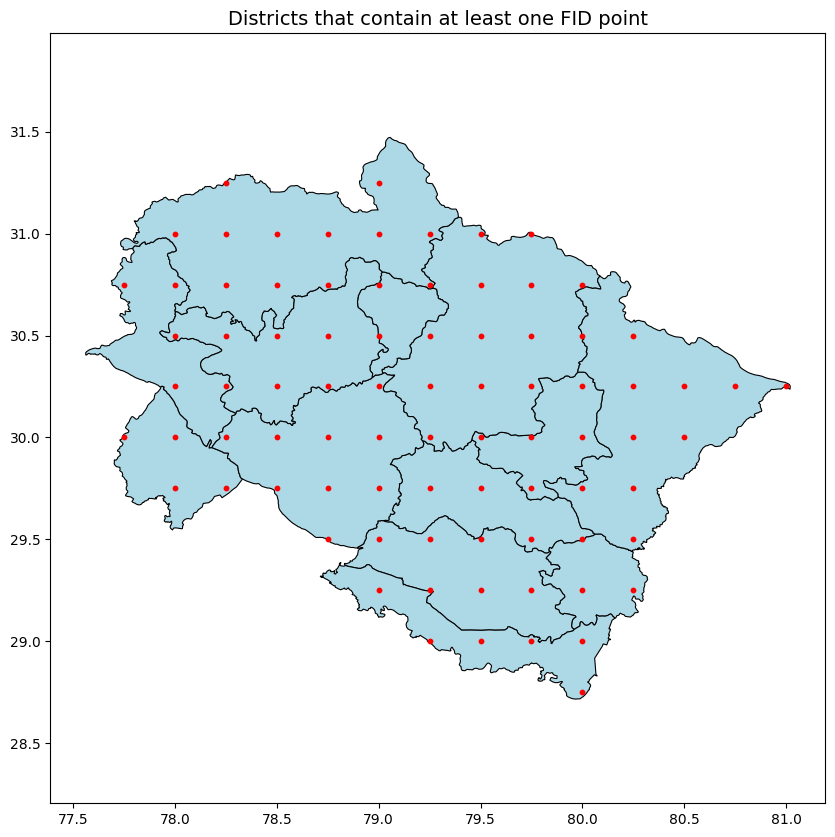

In [5]:
import matplotlib.pyplot as plt

# Step 1: Get unique matched district names
matched_districts = joined['NAME_2'].dropna().unique()

# Step 2: Filter districts GeoDataFrame to only those
matched_polygons = districts[districts['NAME_2'].isin(matched_districts)]

# Step 3: Plot
fig, ax = plt.subplots(figsize=(10, 10))
matched_polygons.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)
points.plot(ax=ax, color='red', markersize=10)
ax.set_title("Districts that contain at least one FID point", fontsize=14)
plt.axis('equal')
plt.show()


/tmp/ipykernel_31/4233236503.py:54: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


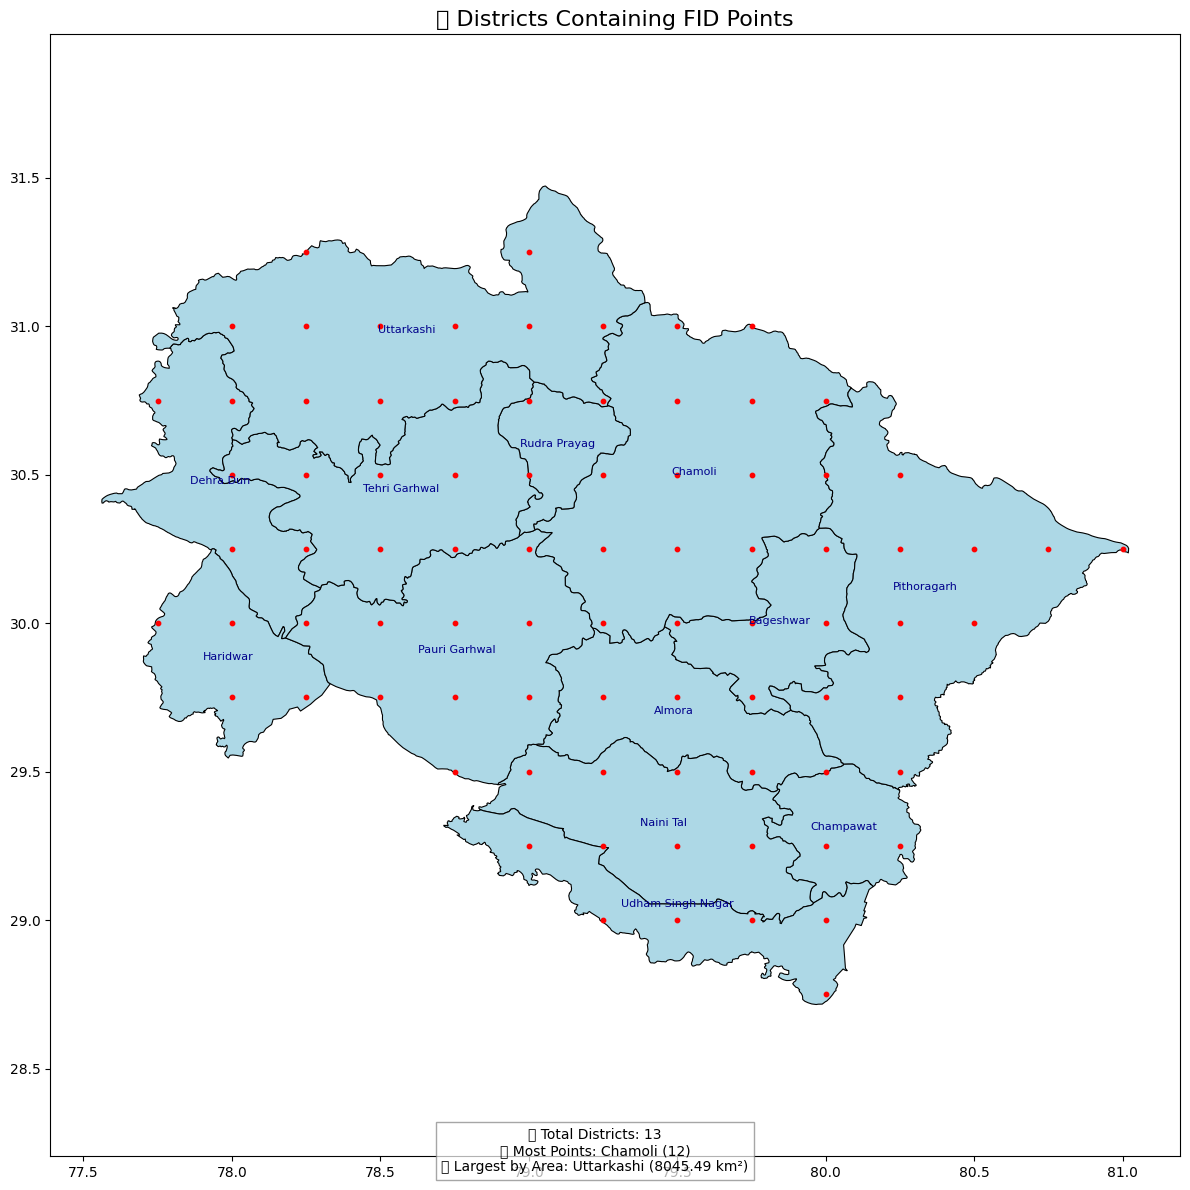

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# ──────────────────────────────────────────────
# 🧱 Step 0: Set up your data (you should already have these loaded)
# 'points' : GeoDataFrame of your FID points
# 'districts' : GeoDataFrame with district polygons
# 'joined' : result of spatial join between points and districts
# ──────────────────────────────────────────────

# 🧭 Step 1: Get matched district polygons
matched_districts = joined['NAME_2'].dropna().unique()
districts['area_km2'] = districts.to_crs(epsg=6933).geometry.area / 1e6  # Equal-area CRS for accurate area
matched_polygons = districts[districts['NAME_2'].isin(matched_districts)].copy()

# 🔢 Step 2: District with most points
point_counts = joined['NAME_2'].value_counts()
district_most_points = point_counts.idxmax()
most_points_count = point_counts.max()

# 🌍 Step 3: District with largest area (now that area_km2 exists in matched_polygons)
largest_area_row = matched_polygons.loc[matched_polygons['area_km2'].idxmax()]
district_largest_area = largest_area_row['NAME_2']
largest_area_km2 = largest_area_row['area_km2']

# 🧮 Step 4: Total number of matched districts
total_districts = len(matched_districts)

# 🖼️ Step 5: Plotting
fig, ax = plt.subplots(figsize=(12, 12))
matched_polygons.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.8)
points.plot(ax=ax, color='red', markersize=10)

# 🏷️ Annotate district names
for idx, row in matched_polygons.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['NAME_2'], fontsize=8, ha='center', color='darkblue')

# 🧾 Title & Summary
ax.set_title("📌 Districts Containing FID Points", fontsize=16)

# 🗒️ Add summary text box
summary_text = (
    f"📍 Total Districts: {total_districts}\n"
    f"🏆 Most Points: {district_most_points} ({most_points_count})\n"
    f"🌍 Largest by Area: {district_largest_area} ({largest_area_km2:.2f} km²)"
)
plt.gcf().text(0.5, 0.02, summary_text, fontsize=10, ha='center',
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.axis('equal')
plt.tight_layout()
plt.show()


In [7]:
import folium
import geopandas as gpd
from folium.plugins import MarkerCluster
from shapely.geometry import Point

# ──────────────────────────────────────────────
# 📍 Step 1: Base Map centered on matched districts
center = matched_polygons.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=7, tiles="cartodbpositron")

# 🧭 Step 2: Add district polygons as interactive vector layer
folium.GeoJson(
    matched_polygons,
    name="Matched Districts",
    tooltip=folium.GeoJsonTooltip(
        fields=["NAME_2", "area_km2"],
        aliases=["District", "Area (km²)"],
        localize=True,
        sticky=False,
        labels=True
    ),
    style_function=lambda feature: {
        'fillColor': '#3186cc',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.4
    },
    highlight_function=lambda x: {'weight': 3, 'color': 'blue'},
).add_to(m)

# 🔴 Step 3: Add points (clustered for better performance)
marker_cluster = MarkerCluster().add_to(m)
for _, row in points.iterrows():
    coords = row.geometry
    folium.CircleMarker(
        location=[coords.y, coords.x],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.7,
        popup=f"Point in {row['NAME_2']}" if 'NAME_2' in row else "FID Point"
    ).add_to(marker_cluster)

# 📝 Step 4: Add a summary HTML popup
summary_html = f"""
<b>Total Matched Districts:</b> {total_districts}<br>
<b>District with Most Points:</b> {district_most_points} ({most_points_count})<br>
<b>Largest District by Area:</b> {district_largest_area} ({largest_area_km2:.2f} km²)
"""
folium.Marker(
    location=[center.y, center.x],
    icon=folium.Icon(color='green', icon='info-sign'),
    popup=folium.Popup(summary_html, max_width=300)
).add_to(m)

# ✅ Step 5: Layer control and show map
folium.LayerControl().add_to(m)
m


In [8]:
import pandas as pd
import numpy as np

# Load the CSV
YEAR = 1957
DATA_PATH = "/kaggle/input/rainfall-1901-1999/1957uk.csv"
df = pd.read_csv(DATA_PATH)

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Replace all NaNs with 0 (or another value if needed)
df.fillna(0, inplace=True)

# Optionally ensure all Day_x columns are numeric
day_cols = [col for col in df.columns if col.startswith("Day_")]
df[day_cols] = df[day_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Check the result
print(df.describe())

             FID      Day_1      Day_2      Day_3      Day_4  Day_5  \
count  83.000000  83.000000  83.000000  83.000000  83.000000   83.0   
mean   41.000000   0.301205  10.915663   7.759036   1.277108    0.0   
std    24.103942   1.904647  10.951339  12.198151   2.683796    0.0   
min     0.000000   0.000000   0.000000   0.000000   0.000000    0.0   
25%    20.500000   0.000000   3.000000   1.000000   0.000000    0.0   
50%    41.000000   0.000000   7.000000   2.000000   0.000000    0.0   
75%    61.500000   0.000000  17.500000   7.000000   0.500000    0.0   
max    82.000000  17.000000  48.000000  55.000000  12.000000    0.0   

           Day_6      Day_7      Day_8      Day_9  ...  Day_357  Day_358  \
count  83.000000  83.000000  83.000000  83.000000  ...     83.0     83.0   
mean    4.602410   5.469880  12.530120  26.927711  ...      0.0      0.0   
std     9.832673  10.358615   8.021826  12.379944  ...      0.0      0.0   
min     0.000000   0.000000   1.000000   1.000000  ...  

In [9]:
# Check the result
print(df.head())
print(df.columns)


   FID  Day_1  Day_2  Day_3  Day_4  Day_5  Day_6  Day_7  Day_8  Day_9  ...  \
0    0      0      0      1      0      0      0      0      2     20  ...   
1    1      0      1      3      0      0      0      0      1     28  ...   
2    2      0      0      4      0      0      0      0      2     25  ...   
3    3      0      0      1      0      0      0      0      7     27  ...   
4    4      0      0      1      0      0      0      0      3     22  ...   

   Day_357  Day_358  Day_359  Day_360  Day_361  Day_362  Day_363  Day_364  \
0        0        0        0        0        0        0        0        0   
1        0        0        0        0        0        0        0        0   
2        0        0        0        0        0        0        0        0   
3        0        0        0        0        0        0        0        0   
4        0        0        0        0        0        0        0        0   

   Day_365  Unnamed: 377  
0        0           0.0  
1        0    

In [10]:
# ─── 2. MELT TO LONG FORMAT ──────────────────────────────────────────────────
df_long = (
    df
    .melt(id_vars=["FID"], value_vars=day_cols, var_name="Day", value_name="Rainfall")
    .assign(
        Day=lambda d: d["Day"].str.extract(r"Day_(\d+)").astype(int),
        Date=lambda d: pd.to_datetime(f"{YEAR}-01-01") + pd.to_timedelta(d["Day"]-1, unit="D")
    )
)
df_long["Month"] = df_long["Date"].dt.month
df_long["Week"]  = df_long["Date"].dt.isocalendar().week

# ─── 3. DEFINE SEASONS ───────────────────────────────────────────────────────
# Meteorological
season_map = {
    **dict.fromkeys([12,1,2], "Winter"),
    **dict.fromkeys([3,4,5], "Spring"),
    **dict.fromkeys([6,7,8], "Summer"),
    **dict.fromkeys([9,10,11], "Autumn"),
}
df_long["Season"] = df_long["Month"].map(season_map)

# Indian monsoon style
monsoon_map = {
    **dict.fromkeys([1,2],  "Winter"),
    **dict.fromkeys([3,4,5],  "Pre-monsoon"),
    **dict.fromkeys([6,7,8,9],  "Monsoon"),
    **dict.fromkeys([10,11,12],"Post-monsoon"),
}
df_long["Monsoon_Season"] = df_long["Month"].map(monsoon_map).fillna("Other")

# ─── 4. AGGREGATIONS ─────────────────────────────────────────────────────────
agg_kwargs = {
    "heavy_count": ("Rainfall", lambda x: (x>100).sum()),
    "heavy_max":   ("Rainfall", "max"),
}

month_summary = (
    df_long.groupby("Month")
           .agg(**agg_kwargs,
                wet_days=("Rainfall", lambda x:(x>0).sum()),
                dry_days=("Rainfall", lambda x:(x==0).sum()))
           .reset_index()
)

week_summary = df_long.groupby("Week").agg(**agg_kwargs).reset_index()
season_summary = df_long.groupby("Season").agg(**agg_kwargs).reset_index()
monsoon_summary = df_long.groupby("Monsoon_Season").agg(**agg_kwargs).reset_index()



In [11]:
print("Week_Summary")
print(week_summary)
print("Season_Summary")
print(season_summary)
print("Monsoon_Summary")
print(monsoon_summary)
print("Df_long")
print(df_long)

Week_Summary
    Week  heavy_count  heavy_max
0      1            0         55
1      2            0         70
2      3            0         36
3      4            0          2
4      5            0         49
5      6            0         11
6      7            0          2
7      8            0          5
8      9            0          8
9     10            0         37
10    11            0         14
11    12            0         24
12    13            0         28
13    14            0         74
14    15            0         32
15    16            0          5
16    17            0         15
17    18            0          9
18    19            0         31
19    20            0         67
20    21            0         51
21    22            0         64
22    23            0         42
23    24            0         25
24    25            0         20
25    26            0         36
26    27            0         78
27    28            3        116
28    29            9        1

In [12]:
# ─── 5. INSIGHTS ─────────────────────────────────────────────────────────────
# Top rainfall days
top_days = df_long[df_long["Rainfall"] > 100].sort_values("Rainfall", ascending=False)
print("\n🔹 Top Rainfall Days > 100 mm:")
print(top_days[["FID", "Date", "Rainfall"]].head())

# Longest dry spell (rainfall == 0)
dry_spell = df_long.groupby("FID")["Rainfall"].apply(lambda x: (x == 0).astype(int))
longest_dry = dry_spell.groupby(df_long["FID"]).apply(lambda x: (x.groupby((x != x.shift()).cumsum()).sum().max()))
print("\n🌵 Longest Dry Spell (consecutive 0 rainfall days):")
print(longest_dry.describe())

# Rainiest locations (top 5)
rainiest = df_long.groupby("FID")["Rainfall"].sum().nlargest(5)
print("\n🌧️ Top 5 Rainiest Grid Cells (by annual rainfall):")
print(rainiest)




🔹 Top Rainfall Days > 100 mm:
       FID       Date  Rainfall
21344   13 1957-09-15       267
18511    2 1957-08-12       222
21359   28 1957-09-15       214
21353   22 1957-09-15       198
21349   18 1957-09-15       194

🌵 Longest Dry Spell (consecutive 0 rainfall days):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Rainfall, dtype: float64

🌧️ Top 5 Rainiest Grid Cells (by annual rainfall):
FID
54    2919
55    2511
66    2511
67    2397
13    2370
Name: Rainfall, dtype: int64


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


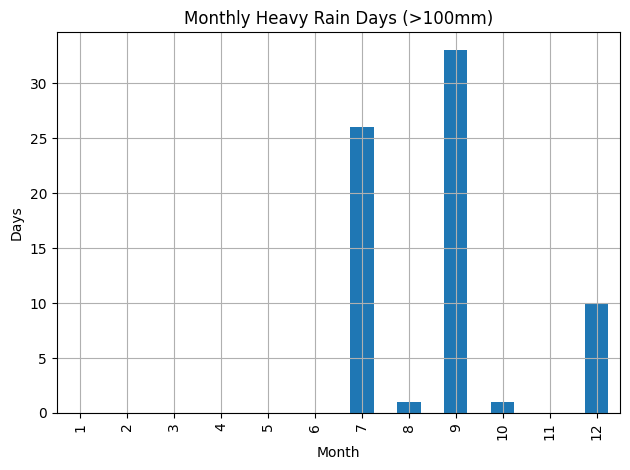

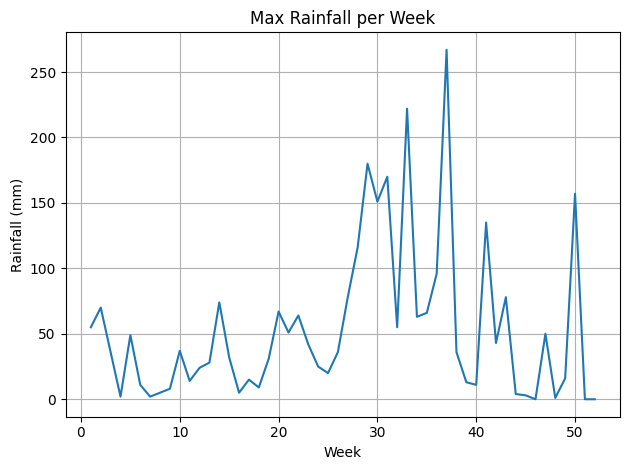

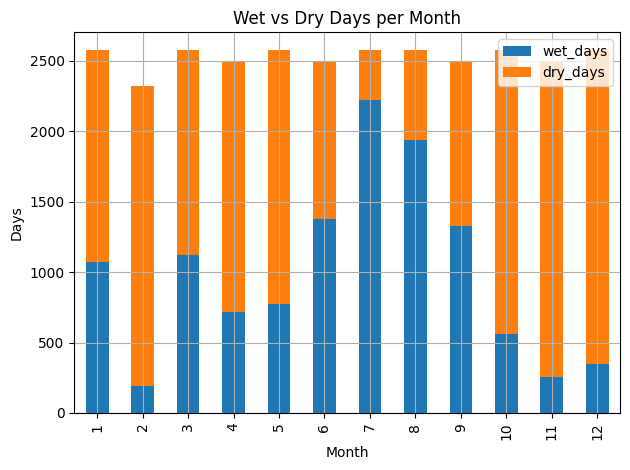

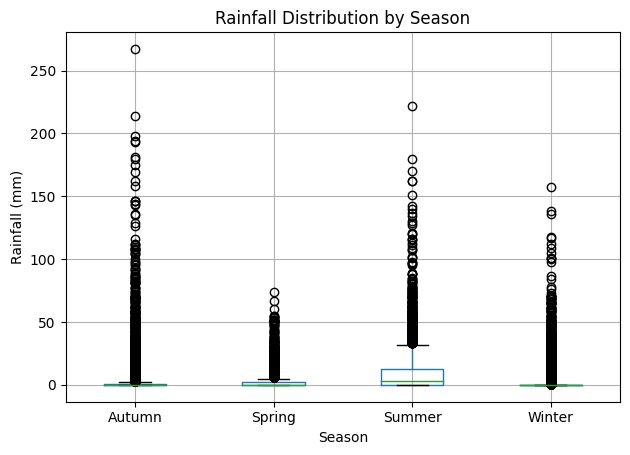

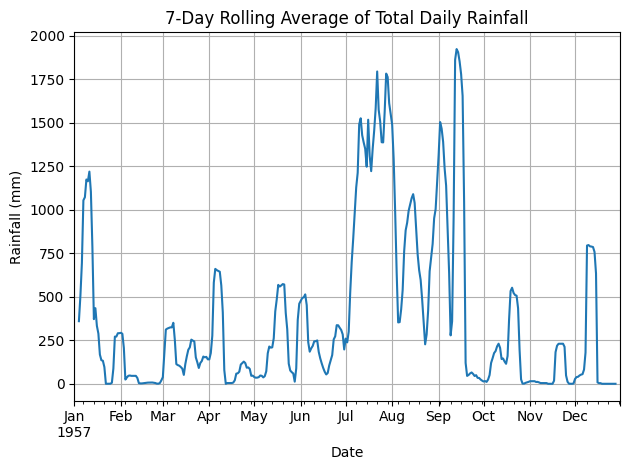

In [13]:
# ─── 6. PLOTTING ─────────────────────────────────────────────────────────────
# Monthly Heavy Rain Count
month_summary.plot.bar(x="Month", y="heavy_count", legend=False, title="Monthly Heavy Rain Days (>100mm)")
plt.ylabel("Days")
plt.grid(True)
plt.tight_layout()
plt.show()

# Weekly Max Rainfall
week_summary.plot(x="Week", y="heavy_max", legend=False, title="Max Rainfall per Week")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Monthly Wet/Dry Days
month_summary[["Month", "wet_days", "dry_days"]].plot.bar(x="Month", stacked=True, title="Wet vs Dry Days per Month")
plt.ylabel("Days")
plt.grid(True)
plt.tight_layout()
plt.show()

# Rainfall Boxplot per Season
df_long.boxplot(column="Rainfall", by="Season")
plt.title("Rainfall Distribution by Season")
plt.suptitle("")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Rolling 7-day average of total rainfall
rolling_avg = (
    df_long.groupby("Date")["Rainfall"]
    .sum()
    .rolling(window=7, center=True)
    .mean()
)
rolling_avg.plot(title="7-Day Rolling Average of Total Daily Rainfall")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()


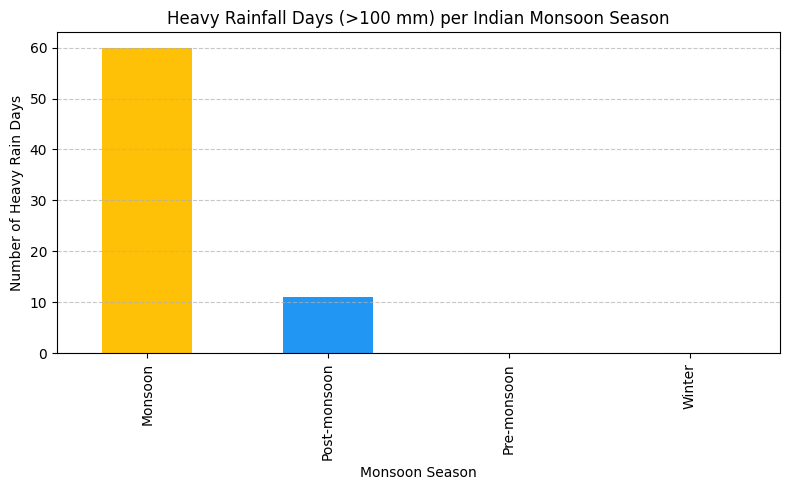

In [14]:
# ─── MONSOON SEASONAL CHART ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
monsoon_summary.sort_values("Monsoon_Season").plot.bar(
    x="Monsoon_Season",
    y="heavy_count",
    legend=False,
    ax=ax,
    color=["#FFC107", "#2196F3", "#4CAF50", "#9E9E9E"]  # Custom color palette
)

ax.set_title("Heavy Rainfall Days (>100 mm) per Indian Monsoon Season")
ax.set_xlabel("Monsoon Season")
ax.set_ylabel("Number of Heavy Rain Days")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


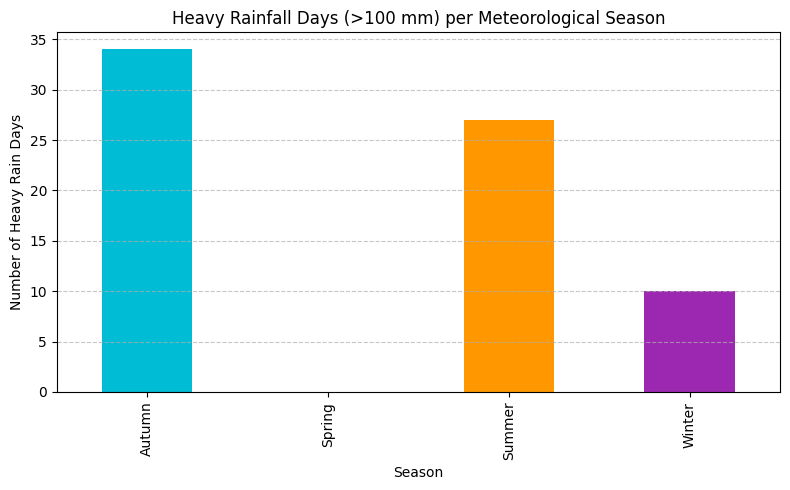

In [15]:
# ─── METEOROLOGICAL SEASONAL CHART ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
season_summary.sort_values("Season").plot.bar(
    x="Season",
    y="heavy_count",
    legend=False,
    ax=ax,
    color=["#00BCD4", "#8BC34A", "#FF9800", "#9C27B0"]  # Colors for Winter → Autumn
)

ax.set_title("Heavy Rainfall Days (>100 mm) per Meteorological Season")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Heavy Rain Days")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Step 1: Create DataFrame from provided list
data = [
    (0, 28.75, 80), (1, 29, 79.25), (2, 29, 79.5), (3, 29, 79.75), (4, 29, 80),
    (5, 29.25, 79), (6, 29.25, 79.25), (7, 29.25, 79.5), (8, 29.25, 79.75), (9, 29.25, 80),
    (10, 29.25, 80.25), (11, 29.5, 78.75), (12, 29.5, 79), (13, 29.5, 79.25), (14, 29.5, 79.5),
    (15, 29.5, 79.75), (16, 29.5, 80), (17, 29.5, 80.25), (18, 29.75, 78), (19, 29.75, 78.25),
    (20, 29.75, 78.5), (21, 29.75, 78.75), (22, 29.75, 79), (23, 29.75, 79.25), (24, 29.75, 79.5),
    (25, 29.75, 79.75), (26, 29.75, 80), (27, 29.75, 80.25), (28, 30, 77.75), (29, 30, 78),
    (30, 30, 78.25), (31, 30, 78.5), (32, 30, 78.75), (33, 30, 79), (34, 30, 79.25),
    (35, 30, 79.5), (36, 30, 79.75), (37, 30, 80), (38, 30, 80.25), (39, 30, 80.5),
    (40, 30.25, 78), (41, 30.25, 78.25), (42, 30.25, 78.5), (43, 30.25, 78.75), (44, 30.25, 79),
    (45, 30.25, 79.25), (46, 30.25, 79.5), (47, 30.25, 79.75), (48, 30.25, 80), (49, 30.25, 80.25),
    (50, 30.25, 80.5), (51, 30.25, 80.75), (52, 30.25, 81), (53, 30.5, 78), (54, 30.5, 78.25),
    (55, 30.5, 78.5), (56, 30.5, 78.75), (57, 30.5, 79), (58, 30.5, 79.25), (59, 30.5, 79.5),
    (60, 30.5, 79.75), (61, 30.5, 80), (62, 30.5, 80.25), (63, 30.75, 77.75), (64, 30.75, 78),
    (65, 30.75, 78.25), (66, 30.75, 78.5), (67, 30.75, 78.75), (68, 30.75, 79), (69, 30.75, 79.25),
    (70, 30.75, 79.5), (71, 30.75, 79.75), (72, 30.75, 80), (73, 31, 78), (74, 31, 78.25),
    (75, 31, 78.5), (76, 31, 78.75), (77, 31, 79), (78, 31, 79.25), (79, 31, 79.5), (80, 31, 79.75),
    (81, 31.25, 78.25), (82, 31.25, 79)
]

df = pd.DataFrame(data, columns=['FID', 'Lat', 'Long'])

# Step 2: Convert to GeoDataFrame
df['geometry'] = df.apply(lambda row: Point(row['Long'], row['Lat']), axis=1)
points = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Step 3: Load India district boundaries
districts = gpd.read_file("/kaggle/input/india-district-data/india_district.geojson")  # Replace with actual path
districts = districts.to_crs("EPSG:4326")

# Step 4: Spatial join to find district for each point
joined = gpd.sjoin(points, districts, how="left", predicate='within')

# Step 5: Group by district and list FIDs
district_fid_map = joined.groupby("NAME_2")["FID"].apply(list).reset_index()
district_fid_map.columns = ["District", "FIDs"]
district_fid_map.sort_values("District", inplace=True)
district_fid_map.head(13)  # Showing only the first 13 districts



,District,FIDs
0,Almora,"[15, 16, 23, 24]"
1,Bageshwar,"[25, 35, 36, 37, 48]"
2,Chamoli,"[34, 45, 46, 47, 58, 59, 60, 70, 71, 72, 79, 80]"
3,Champawat,"[9, 10]"
4,Dehra Dun,"[40, 41, 63, 64]"
5,Haridwar,"[18, 19, 28, 29]"
6,Naini Tal,"[6, 7, 8, 12, 13, 14]"
7,Pauri Garhwal,"[11, 20, 21, 22, 30, 31, 32, 33, 44]"
8,Pithoragarh,"[17, 26, 27, 38, 39, 49, 50, 51, 52, 61, 62]"
9,Rudra Prayag,"[57, 68]"


<Axes: >

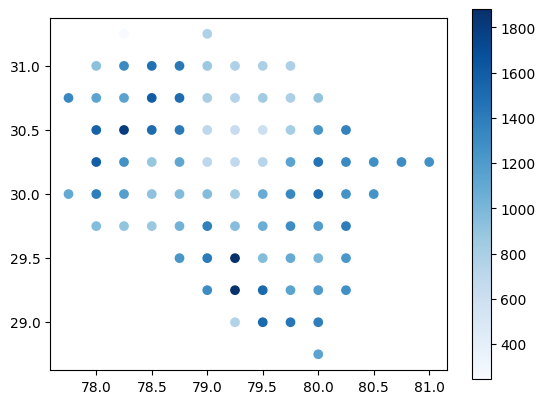

In [27]:
import pandas as pd
import numpy as np

# Load the CSV
df_rainfall = pd.read_csv("/kaggle/input/rainfall-1901-1999/1957uk.csv")

# Replace infinite values with NaN
df_rainfall.replace([np.inf, -np.inf], np.nan, inplace=True)

# Replace all NaNs with 0 (or another value if needed)
df_rainfall.fillna(0, inplace=True)

# Optionally ensure all Day_x columns are numeric
day_cols = [col for col in df_rainfall.columns if col.startswith("Day_")]
df_rainfall[day_cols] = df_rainfall[day_cols].apply(pd.to_numeric, errors='coerce').fillna(0)


# Step 1: Detect days with rainfall > 100mm
rain_columns = [col for col in df_rainfall.columns if col.startswith('Day_')]
mask = df_rainfall[rain_columns] > 100

# Step 2: Get FIDs and corresponding days
high_rainfall = mask.stack()[lambda x: x].reset_index()
high_rainfall.columns = ['FID_index', 'Day', 'HighRain']
high_rainfall['FID'] = df_rainfall.loc[high_rainfall['FID_index'], 'FID'].values

# Step 3: Merge with district mapping
high_rainfall = high_rainfall.merge(joined[['FID', 'NAME_2']], on='FID', how='left')

# Reshape data to long format for easier month mapping
df_long = df_rainfall.melt(id_vars=['FID'], value_vars=rain_columns,
                           var_name='Day', value_name='Rainfall')

# Convert "Day_1" → 1, then map to month
df_long['Day_Num'] = df_long['Day'].str.extract('(\d+)').astype(int)
df_long['Month'] = ((df_long['Day_Num'] - 1) // 30 + 1).clip(upper=12)

# Group and plot
monthly_rain = df_long.groupby(['FID', 'Month'])['Rainfall'].sum().reset_index()

# Define a function to assign seasons
def get_season(day):
    if day <= 59: return 'Winter'
    elif day <= 151: return 'Pre-Monsoon'
    elif day <= 273: return 'Monsoon'
    else: return 'Post-Monsoon'

df_long['Season'] = df_long['Day_Num'].apply(get_season)

# Group by FID and season
seasonal_rain = df_long.groupby(['FID', 'Season'])['Rainfall'].sum().reset_index()

# Example: Plot monsoon rainfall per FID
monsoon_data = seasonal_rain[seasonal_rain['Season'] == 'Monsoon']
merged = joined.merge(monsoon_data, on='FID')

# Plot using GeoPandas
merged.plot(column='Rainfall', cmap='Blues', legend=True)


In [22]:
import pandas as pd
import numpy as np

# Load the rainfall CSV
df_rainfall = pd.read_csv("/kaggle/input/rainfall-1901-1999/1957uk.csv")

# Clean the data
df_rainfall.replace([np.inf, -np.inf], np.nan, inplace=True)
df_rainfall.fillna(0, inplace=True)

# Extract only Day_x columns for analysis
day_cols = [col for col in df_rainfall.columns if col.startswith("Day_")]
df_rainfall[day_cols] = df_rainfall[day_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Reshape from wide to long format for easier analysis
df_long = df_rainfall.melt(id_vars=['FID'], value_vars=day_cols,
                           var_name='Day', value_name='Rainfall')

# Convert Day_1...Day_365 to actual day numbers
df_long['Day'] = df_long['Day'].str.extract('Day_(\d+)').astype(int)

# Add date based on day of year (assuming year 1957)
df_long['Date'] = pd.to_datetime('1957-01-01') + pd.to_timedelta(df_long['Day'] - 1, unit='D')
df_long['Month'] = df_long['Date'].dt.month
df_long['Month_Name'] = df_long['Date'].dt.strftime('%B')

# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Pre-Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df_long['Season'] = df_long['Month'].apply(get_season)
# Step 6: Merge rainfall data with district mapping from spatial join
# (Assuming 'joined' contains columns: FID and NAME_2 as District name)

# 1. Extract mapping of FID to District from spatial join
fid_district_map = joined[['FID', 'NAME_2']].drop_duplicates().rename(columns={'NAME_2': 'District'})

# 2. Merge with df_long
df_long = df_long.merge(fid_district_map, on='FID', how='left')

# Now df_long has District info for each FID
print(df_long[['FID', 'District', 'Date', 'Rainfall']].head())

df_long.head()


   FID           District       Date  Rainfall
0    0  Udham Singh Nagar 1957-01-01         0
1    1  Udham Singh Nagar 1957-01-01         0
2    2  Udham Singh Nagar 1957-01-01         0
3    3  Udham Singh Nagar 1957-01-01         0
4    4  Udham Singh Nagar 1957-01-01         0


,FID,Day,Rainfall,Date,Month,Month_Name,Season,District
0,0,1,0,1957-01-01,1,January,Winter,Udham Singh Nagar
1,1,1,0,1957-01-01,1,January,Winter,Udham Singh Nagar
2,2,1,0,1957-01-01,1,January,Winter,Udham Singh Nagar
3,3,1,0,1957-01-01,1,January,Winter,Udham Singh Nagar
4,4,1,0,1957-01-01,1,January,Winter,Udham Singh Nagar


In [ ]:
# ------------------------------------------------------
# Step 1: Calculate total rainfall for each FID
# ------------------------------------------------------

# Group by FID to compute total rainfall across the year
total_rainfall_fid = df_long.groupby('FID')['Rainfall'].sum().reset_index()

# Rename the column for clarity
total_rainfall_fid.columns = ['FID', 'Total_Rainfall']

# ------------------------------------------------------
# Step 2: Add corresponding district name
# ------------------------------------------------------

# Use the 'joined' GeoDataFrame or mapping created earlier to add district info
# Assumes 'joined' contains FID and a 'District' or 'NAME_2' column
fid_to_district = joined.drop_duplicates(subset='FID')[['FID', 'NAME_2']]
fid_to_district.columns = ['FID', 'District']

# Merge district name with rainfall summary
total_rainfall_fid = total_rainfall_fid.merge(fid_to_district, on='FID', how='left')

# ------------------------------------------------------
# Step 3: Sort and display top FIDs with the most rainfall
# ------------------------------------------------------

# Sort in descending order to get the top rainiest FIDs
top_fids = total_rainfall_fid.sort_values(by='Total_Rainfall', ascending=False)

# Display top 5 FIDs along with district and rainfall info
print("Top 5 FIDs with the highest total annual rainfall:")
print(top_fids[['FID', 'District', 'Total_Rainfall']].head())


In [ ]:
# Filter for days with rainfall greater than 100mm
heavy_rain_days = df_long[df_long['Rainfall'] > 100]

# Add relevant columns for report
heavy_rain_days_report = heavy_rain_days[['FID', 'Date', 'Month_Name', 'District', 'Rainfall']]

# Sort by FID and Date (optional)
heavy_rain_days_report = heavy_rain_days_report.sort_values(by=['District', 'FID', 'Date'])

# Print heavy rainfall report
print(heavy_rain_days_report)

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Get center of the bounding box of all districts
bounds = districts.total_bounds  # [minx, miny, maxx, maxy]
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2
# Perform spatial join to attach district names to each FID point
points_with_districts = gpd.sjoin(points, districts[['NAME_2', 'geometry']], how="left", predicate='within')

# Check to make sure it worked
print(points_with_districts[['FID', 'NAME_2']].dropna().head())

# Initialize the base map
m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="cartodbpositron")

# Add district polygons to the map
folium.GeoJson(
    districts,
    name="Districts",
    tooltip=folium.GeoJsonTooltip(fields=["NAME_2"]),
    style_function=lambda feature: {
        'fillColor': '#3186cc',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.4
    }
).add_to(m)

# Add clustered markers for each FID point with district name
marker_cluster = MarkerCluster().add_to(m)
for _, row in points_with_districts.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.7,
        popup=f"FID: {row['FID']} - District: {row['NAME_2']}"
    ).add_to(marker_cluster)

# Display the map
m


In [ ]:
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import matplotlib

# Get center of the bounding box of all districts
bounds = districts.total_bounds  # [minx, miny, maxx, maxy]
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Sum across all 365 daily columns
rainfall_columns = [col for col in points.columns if col.startswith("Day_")]
points["total_rainfall"] = points[rainfall_columns].sum(axis=1)


# Perform spatial join to attach district names to each FID point
points_with_districts = gpd.sjoin(points, districts[['NAME_2', 'geometry']], how="left", predicate='within')

# OPTIONAL: Normalize rainfall for color mapping
rainfall_values = points_with_districts['total_rainfall']
norm = plt.Normalize(vmin=rainfall_values.min(), vmax=rainfall_values.max())
cmap = plt.colormaps['YlOrRd']

# Initialize the base map
m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="cartodbpositron")

# Add district polygons to the map
folium.GeoJson(
    districts,
    name="Districts",
    tooltip=folium.GeoJsonTooltip(fields=["NAME_2"]),
    style_function=lambda feature: {
        'fillColor': '#3186cc',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.4
    }
).add_to(m)

# Add clustered markers for each FID point with district name and rainfall
marker_cluster = MarkerCluster().add_to(m)
for _, row in points_with_districts.iterrows():
    rainfall = row['total_rainfall']
    color = matplotlib.colors.to_hex(cmap(norm(rainfall)))  # Convert to hex for folium
    
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"""
        <b>FID:</b> {row['FID']}<br>
        <b>District:</b> {row['NAME_2']}<br>
        <b>Total Rainfall:</b> {rainfall:.2f} mm
        """
    ).add_to(marker_cluster)

# Display the map
m


In [ ]:
# vector map ?

/tmp/ipykernel_31/1555830950.py:1282: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  landslide_uk['geometry'] = landslide_uk.apply(
/tmp/ipykernel_31/1555830950.py:1387: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  india = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
/tmp/ipykernel_31/1555830950.py:1394: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


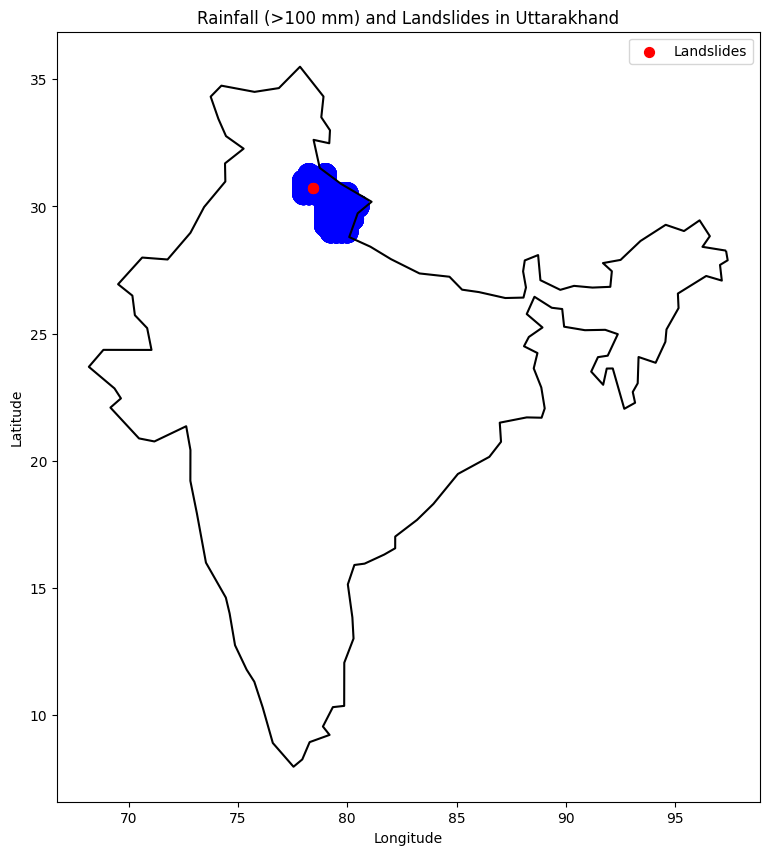

No matches found between rainfall >100 mm and landslides in the same year and within 50 km.

Insights:
Total days with >100 mm rainfall: 1076
Total landslides in Uttarakhand: 3
Matches found: 0


In [25]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Step 1: Process Landslide Data
# Load landslide data (from previous dictionary)
landslide_data = [
    {
        "Date": "September 18, 1948",
        "Places": "Guwahati, Assam",
        "Mortality and Dimension": "500 people died, buried an entire village",
        "Latitude": "26°08’35.71\" N",
        "Longitude": "91°44’10.45\" E"
    },
    {
        "Date": "July, 1968",
        "Places": "Garhwal Himalaya",
        "Mortality and Dimension": "damage to road",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 4, 1968",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "Thousand people died, 60KM long highway cut in 91 parts",
        "Latitude": "27°02’9.62\" N",
        "Longitude": "88°15’45.03\" E"
    },
    {
        "Date": "January, 1982",
        "Places": "Nashri, Jammu & Kashmir",
        "Mortality and Dimension": "road and communication network is damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 1968",
        "Places": "Maling, H.P",
        "Mortality and Dimension": "damaged 1 Km NH-22",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "Dec, 1982",
        "Places": "Kinnaur, H.P",
        "Mortality and Dimension": "occurred at Sholding nala collapsing 3 bridges and 1.5 of road was vanished",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March, 1989",
        "Places": "Jhakri, H.P",
        "Mortality and Dimension": "about 500 m of road was damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October, 1990",
        "Places": "Kundah, Nilgiris",
        "Mortality and Dimension": "36 people killed, several building were damaged",
        "Latitude": "11°15’40.41\" N",
        "Longitude": "76°38’15.95\" E"
    },
    {
        "Date": "July, 1991",
        "Places": "Guwahati, Assam",
        "Mortality and Dimension": "300 people were killed, roads and buildings were damaged",
        "Latitude": "26°12’02.18\" N",
        "Longitude": "92°56’15.27\" E"
    },
    {
        "Date": "1991",
        "Places": "Uttarkashi, U.P.",
        "Mortality and Dimension": "More than 2000 lives lost, houses and bridges damaged",
        "Latitude": "30°43’36.59\" N",
        "Longitude": "78°26’7.46\" E"
    },
    {
        "Date": "1992",
        "Places": "Mizoram",
        "Mortality and Dimension": "Extensive damage to roads in the region",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November, 1992",
        "Places": "Kundah, Nilgiris",
        "Mortality and Dimension": "Road network damaged & loss of property over Rs. 5 millions",
        "Latitude": "11°15’40.41\" N",
        "Longitude": "76°38’15.95\" E"
    },
    {
        "Date": "Feb 25, 1993",
        "Places": "Kinnaur, H.P",
        "Mortality and Dimension": "affected the highway, NH-22 (450m), blocking for two months",
        "Latitude": "31°39’3.45\" N",
        "Longitude": "78°28’31.71\" E"
    },
    {
        "Date": "May 10, 1993",
        "Places": "Kaki Khola, Sonpur Division, Tripura",
        "Mortality and Dimension": "collapse of house, 6 person buried alive, and a few injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 3, 1993",
        "Places": "Mizoram",
        "Mortality and Dimension": "Three killed and several injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 9, 1993",
        "Places": "Thiruvanantapuram",
        "Mortality and Dimension": "8 killed and property damaged",
        "Latitude": "8°31’26.63\" N",
        "Longitude": "76°56’37.96\" E"
    },
    {
        "Date": "June 20, 1993",
        "Places": "China Chip Village, Aizwal",
        "Mortality and Dimension": "Five killed in landslides",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "July, 1993",
        "Places": "Aizawl",
        "Mortality and Dimension": "4 persons buried",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "July 1, 1993",
        "Places": "Itanagar, Arunachal Pradesh",
        "Mortality and Dimension": "25 people were buried alive",
        "Latitude": "27°05’3.73\" N",
        "Longitude": "93°36’19.14\" E"
    },
    {
        "Date": "August 5, 1993",
        "Places": "Kalimpong, West Bengal",
        "Mortality and Dimension": "40 people were killed, heavy loss of property",
        "Latitude": "27°03’33.68\" N",
        "Longitude": "88°28’10.03\" E"
    },
    {
        "Date": "August 21, 1993",
        "Places": "Urni, H.P.",
        "Mortality and Dimension": "A jeep with its occupants was buried on H.T. road, 40 km from Shimla",
        "Latitude": "31°31’57.99\" N",
        "Longitude": "78°07’46.89\" E"
    },
    {
        "Date": "August 17, 1993",
        "Places": "Kohima, Nagaland",
        "Mortality and Dimension": "200 houses destroyed, 500 people died, 5 km road was damaged",
        "Latitude": "26°09’30.37\" N",
        "Longitude": "94°33’44.79\" E"
    },
    {
        "Date": "September 12, 1993",
        "Places": "Ratighat, U.P.",
        "Mortality and Dimension": "Nainital Hill area remained cutoff for about a week",
        "Latitude": "29°22’43.15\" N",
        "Longitude": "79°27’94.81\" E"
    },
    {
        "Date": "November, 1993",
        "Places": "Nilgiri, Tamil Nadu",
        "Mortality and Dimension": "408 Landslides occurred, Marapplam killed 40 people and destroyed property",
        "Latitude": "11°29’22.44\" N",
        "Longitude": "76°44’26.44\" E"
    },
    {
        "Date": "1993",
        "Places": "Jammu and Kashmir",
        "Mortality and Dimension": "Road Blockage",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "Jan-94",
        "Places": "Kashmir",
        "Mortality and Dimension": "National Highway 1A severely damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 1994",
        "Places": "Varundh ghat, Konkan Coast",
        "Mortality and Dimension": "20 people were killed, 1km of road was damaged",
        "Latitude": "18°58’31.46\" N",
        "Longitude": "72°54’45.92\" E"
    },
    {
        "Date": "May, 1995",
        "Places": "Aizawl, Mizoram",
        "Mortality and Dimension": "25 people killed, road damaged",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "June, 1995",
        "Places": "Malari, J&K",
        "Mortality and Dimension": "6 persons killed. NH 1A damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 12, 1995",
        "Places": "Luggarbhati, H.P",
        "Mortality and Dimension": "39 were buried alive",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 1995",
        "Places": "Kullu, H.P.",
        "Mortality and Dimension": "22 persons killed, 1km road damaged",
        "Latitude": "31°57’28.26\" N",
        "Longitude": "77°06’31.05\" E"
    },
    {
        "Date": "July 11-12, 1996",
        "Places": "Jaldhaka valley and South Kalimpong hills",
        "Mortality and Dimension": "32 lives lost, damages to huge property",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 9, 1997",
        "Places": "Gangtok",
        "Mortality and Dimension": "Widespread devastation of Gangtok town",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 14, 1998",
        "Places": "Okhimath, Uttarakhand",
        "Mortality and Dimension": "69 people were killed",
        "Latitude": "30°30’53.57\" N",
        "Longitude": "79°05’45.47\" E"
    },
    {
        "Date": "August 18, 1998",
        "Places": "Malpa, Uttaranchal",
        "Mortality and Dimension": "200 people perished",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 7, 1999",
        "Places": "Kurseong town",
        "Mortality and Dimension": "Kurseong town devastated",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 12, 2000",
        "Places": "Mumbai, Maharashtra",
        "Mortality and Dimension": "67 people were killed",
        "Latitude": "19°04’33.54\" N",
        "Longitude": "72°52’39.56\" E"
    },
    {
        "Date": "November 9, 2001",
        "Places": "Amboori, Kerala",
        "Mortality and Dimension": "39 people were killed",
        "Latitude": "8°30’14.84\" N",
        "Longitude": "77°11’29.94\" E"
    },
    {
        "Date": "Sept 23, 2003",
        "Places": "Varunavat parvat, Uttarkashi",
        "Mortality and Dimension": "led to the blockage of the pilgrim route to Gangotri",
        "Latitude": "30°43’36.71\" N",
        "Longitude": "78°26’09.67\" E"
    },
    {
        "Date": "September, 2004",
        "Places": "Uttarkashi, Uttrakhand",
        "Mortality and Dimension": "3 four storeyed hotel building buried completely and NH 72 blocked for several days, posed risk to of about 200 houses at footslopes",
        "Latitude": "30°43’36.71\" N",
        "Longitude": "78°26’09.67\" E"
    },
    {
        "Date": "July 5, 2004",
        "Places": "Badrinath, Chamoli, Uttarakhand",
        "Mortality and Dimension": "16 persons killed, 200 pilgrims stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2005",
        "Places": "Raigad",
        "Mortality and Dimension": "54 people were killed",
        "Latitude": "18°30’56.71\" N",
        "Longitude": "73°10’55.78\" E"
    },
    {
        "Date": "July 26, 2005",
        "Places": "Sakinaka, Mumbai",
        "Mortality and Dimension": "74 people were killed",
        "Latitude": "19°05’41.62\" N",
        "Longitude": "72°53’11.49\" E"
    },
    {
        "Date": "August, 2005",
        "Places": "Mumbai",
        "Mortality and Dimension": "Buildings collapsed and people buried",
        "Latitude": "19°05’41.62\" N",
        "Longitude": "72°53’11.49\" E"
    },
    {
        "Date": "October 8, 2005",
        "Places": "Kashmir",
        "Mortality and Dimension": "1000 fatalities, destroying roads, and disrupting communications",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2006",
        "Places": "Mangalore, Karnataka",
        "Mortality and Dimension": "Several Building at risk due to landslide",
        "Latitude": "12°54’50.91\" N",
        "Longitude": "74°51’21.44\" E"
    },
    {
        "Date": "August 14, 2007",
        "Places": "Dharla village, H.P",
        "Mortality and Dimension": "Burial of entire village",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 15, 2007",
        "Places": "Ladakh",
        "Mortality and Dimension": "6 injured, 2 died",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 17, 2009",
        "Places": "Brari marg on the Baltat route, J&K",
        "Mortality and Dimension": "1 killed, 4 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 30, 2009",
        "Places": "Adoshi tunnel at Khandala ghat, on the Pune-Mumbai expressway",
        "Mortality and Dimension": "1 killed, 5 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 21, 2009",
        "Places": "Syara, Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "Three members of a family were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2009",
        "Places": "Gopeshwar, Chamoli, Uttarakhand",
        "Mortality and Dimension": "two labourers were killed and 4 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2009",
        "Places": "Jumma on Joshimath Malari road",
        "Mortality and Dimension": "three persons of a family",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 27, 2009",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "Balipara-Tawang Road to Sino-India border was cut off",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 1, 2009",
        "Places": "Kyongsala, Sikkim",
        "Mortality and Dimension": "claimed the life of a Border Roads Organisation (BRO) labourer",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 29, 2009",
        "Places": "Vaishnodevi, Reasi, J&K",
        "Mortality and Dimension": "a woman pilgrim was killed and two others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 2, 2009",
        "Places": "Rangrik, Lahaul and Spiti, H.P",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 7, 2009",
        "Places": "Kumarda, H.P",
        "Mortality and Dimension": "destroyed three houses, three cowsheds, and washed away 10 animals and a private bus",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 8, 2009",
        "Places": "Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "Three villages viz. Chachna, Lah and Rumiadola were swept away",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 16, 2009",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "leading to blockade of main road link (NH55) between Siliguri and Darjeeling",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 16, 2009",
        "Places": "Dunali, Bharmor to Dharmashala",
        "Mortality and Dimension": "death of one person and has seriously injured seven others",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 17, 2009",
        "Places": "Champawat, Uttarakhand",
        "Mortality and Dimension": "two persons were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 20, 2009",
        "Places": "Jorabat and Sonapur, Assam",
        "Mortality and Dimension": "NH-37 was blocked",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 20, 2009",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "three persons were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 28, 2009",
        "Places": "Munsiari Tehsi, Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "a person was killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 28, 2009",
        "Places": "North Cachar Hills district, Assam",
        "Mortality and Dimension": "train services were disrupted on the 184-km metre gauge track from Lumding to Badarpur",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 2, 2009",
        "Places": "Chinona, Almora, Uttarakhand",
        "Mortality and Dimension": "three people were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 3, 2009",
        "Places": "Andheri, Mumbai",
        "Mortality and Dimension": "12 people were killed and 13 others injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 5, 2009",
        "Places": "Gorshila, Uttarakhand",
        "Mortality and Dimension": "led to the traffic disruption for seven hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 8, 2009",
        "Places": "Uttarakhand",
        "Mortality and Dimension": "three persons were killed and five others injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 2, 2009",
        "Places": "Canacona, Goa",
        "Mortality and Dimension": "the services on Konkan railway route were severely affected",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 2, 2009",
        "Places": "Madibagh, Uttara Kannada",
        "Mortality and Dimension": "24 people were buried alive when nine houses collapsed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 3, 2009",
        "Places": "Kozhikode, Kerala",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 6, 2009",
        "Places": "Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "a big group of tourists was stranded due to blocking of highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 26, 2009",
        "Places": "Belthangady taluk, Karnataka",
        "Mortality and Dimension": "a construction worker was killed and two others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 8, 2009",
        "Places": "Manthada, Nilgiri",
        "Mortality and Dimension": "five members of a family were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 10, 2009",
        "Places": "Ooty, Tamilnadu",
        "Mortality and Dimension": "killing at least 39 people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 16, 2009",
        "Places": "Chamba-Jot road, Himachal Pradesh",
        "Mortality and Dimension": "The road was closed for traffic for about four hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 12, 2009",
        "Places": "Nag Post, Keran Sector, Kupwara, J&K",
        "Mortality and Dimension": "A BSF porter was feared killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "January 3, 2010",
        "Places": "Vaishnodevi in Trikuta hills of Reasi district, Jammu & Kashmir",
        "Mortality and Dimension": "left a pilgrim injured",
        "Latitude": "33.0308° N",
        "Longitude": "74.9490° E"
    },
    {
        "Date": "February 8-9, 2010",
        "Places": "Kalath on the Manali-Kullu highway (on NH-22)",
        "Mortality and Dimension": "Both the road stretches from Kullu - one from the Naggar side and the second the main national highway were blocked at various points",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 8, 2010",
        "Places": "Narundi area of Uri, Baramulla",
        "Mortality and Dimension": "1 person was killed and 6 others were injured",
        "Latitude": "34.0881° N",
        "Longitude": "74.0340° E"
    },
    {
        "Date": "February 14, 2010",
        "Places": "Kachsthal village, Kinnaur",
        "Mortality and Dimension": "6 persons were killed and 14 others injured",
        "Latitude": "31°39’3.45\" N",
        "Longitude": "78°28’31.71\" E"
    },
    {
        "Date": "February 22, 2010",
        "Places": "Chairvani Village, Ganderbal, J & K",
        "Mortality and Dimension": "1 person was killed and 6 injured",
        "Latitude": "34.2165° N",
        "Longitude": "74.7719° E"
    },
    {
        "Date": "February 23, 2010",
        "Places": "Tangadia, Tehri, Uttarakhand",
        "Mortality and Dimension": "2 children were killed and another injured",
        "Latitude": "30.3012° N",
        "Longitude": "78.5661° E"
    },
    {
        "Date": "February 25, 2010",
        "Places": "Granite quarry, Ongole, Prakasam, Andhra Pradesh",
        "Mortality and Dimension": "about 20 workers were feared killed",
        "Latitude": "15.5057° N",
        "Longitude": "80.0499° E"
    },
    {
        "Date": "February 27, 2010",
        "Places": "Vaishno Devi, Katra, J&K",
        "Mortality and Dimension": "2 pilgrims died",
        "Latitude": "33.0308° N",
        "Longitude": "74.9490° E"
    },
    {
        "Date": "March 27, 2010",
        "Places": "LangthAbal Khoupum, Imphal, Manipur",
        "Mortality and Dimension": "1 house was completely damaged",
        "Latitude": "24.8170° N",
        "Longitude": "93.9368° E"
    },
    {
        "Date": "April 2, 2010",
        "Places": "Koloriang, Kurung Kumey, Arunachal Pradesh",
        "Mortality and Dimension": "7 people were killed",
        "Latitude": "27.900° N",
        "Longitude": "93.350° E"
    },
    {
        "Date": "April 20, 2010",
        "Places": "Srinagar-Ladakh highway",
        "Mortality and Dimension": "The highway was closed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 21, 2010",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "12 people have died",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 12, 2010",
        "Places": "Jaintia Hills, Meghalaya",
        "Mortality and Dimension": "disrupted the traffic to Tripura, Mizoram and southern Assam",
        "Latitude": "25°30’07.66\" N",
        "Longitude": "92°20’30.79\" E"
    },
    {
        "Date": "May 18, 2010",
        "Places": "Chang La top, Jammu and Kashmir",
        "Mortality and Dimension": "2 persons were killed, 73 other persons trapped",
        "Latitude": "34.0472° N",
        "Longitude": "77.9305° E"
    },
    {
        "Date": "May 20, 2010",
        "Places": "Vijaywada, Andhra Pradesh",
        "Mortality and Dimension": "4 people were killed",
        "Latitude": "16.5062° N",
        "Longitude": "80.6480° E"
    },
    {
        "Date": "May 25, 2010",
        "Places": "Chadiyan village, Uri, J&K",
        "Mortality and Dimension": "damaged several houses",
        "Latitude": "34.0881° N",
        "Longitude": "74.0340° E"
    },
    {
        "Date": "June 3, 2010",
        "Places": "Rongpur, Karimganj, Assam",
        "Mortality and Dimension": "2 persons dead and 5 others injured",
        "Latitude": "24.6005° N",
        "Longitude": "92.3814° E"
    },
    {
        "Date": "June 8, 2010",
        "Places": "Irang, Manipur",
        "Mortality and Dimension": "suspended traffic along the highway (NH53)",
        "Latitude": "24.76383° N",
        "Longitude": "93.85573° E"
    },
    {
        "Date": "June 9, 2010",
        "Places": "Shimla, Himachal Pradesh",
        "Mortality and Dimension": "resulted in road blocks",
        "Latitude": "31.1048° N",
        "Longitude": "77.1734° E"
    },
    {
        "Date": "June 9, 2010",
        "Places": "Kempty falls, Mussoorie, Uttarakhand",
        "Mortality and Dimension": "damaged 4 vehicles including a bus",
        "Latitude": "30.4873° N",
        "Longitude": "78.0363° E"
    },
    {
        "Date": "June 16, 2010",
        "Places": "Kalimpong, Darjeeling",
        "Mortality and Dimension": "3 people died and 2 others injured",
        "Latitude": "27.0594° N",
        "Longitude": "88.4695° E"
    },
    {
        "Date": "June 16, 2010",
        "Places": "Wadringdisa, North Cachar Hills, Assam",
        "Mortality and Dimension": "disrupted train services",
        "Latitude": "25.3478004° N",
        "Longitude": "93.0175712° E"
    },
    {
        "Date": "June 19, 2010",
        "Places": "Harnai, Ratnagiri, Maharashtra",
        "Mortality and Dimension": "buried 2 houses killing 8 persons",
        "Latitude": "17.8032698° N",
        "Longitude": "73.102383° E"
    },
    {
        "Date": "June 28, 2010",
        "Places": "Shillong, Meghalaya",
        "Mortality and Dimension": "girl was killed and at least 7 others were injured",
        "Latitude": "25.5788° N",
        "Longitude": "91.8933° E"
    },
    {
        "Date": "July 3, 2010",
        "Places": "National Highway 55, West Bengal",
        "Mortality and Dimension": "led to the suspension of the services of Darjeeling Himalayan Railway (DHR)",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 11, 2010",
        "Places": "Rani nullah, H.P",
        "Mortality and Dimension": "The traffic to Manali-Keylong and Leh and Pangi, Kaza and Spiti came to a standstill",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 14, 2010",
        "Places": "Tingda, North Sikkim",
        "Mortality and Dimension": "blocked the Mangan-Gangtok Highway",
        "Latitude": "27.3965° N",
        "Longitude": "88.6368° E"
    },
    {
        "Date": "July 22, 2011",
        "Places": "Patlot-Aghora road, Almora",
        "Mortality and Dimension": "led to the death of 1 person",
        "Latitude": "29.8150° N",
        "Longitude": "79.2902° E"
    },
    {
        "Date": "July 25, 2010",
        "Places": "Panthal, J&K",
        "Mortality and Dimension": "blocked the Jammu-Srinagar highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 25, 2010",
        "Places": "Kanlog, Shimla",
        "Mortality and Dimension": "2 labourers lost their lives and 3 people were injured",
        "Latitude": "31.1048° N",
        "Longitude": "77.1734° E"
    },
    {
        "Date": "July 28, 2010",
        "Places": "Maram, Manipur",
        "Mortality and Dimension": "has cut off the Imphal-Mao section of the NH-39",
        "Latitude": "25.4236° N",
        "Longitude": "94.1066° E"
    },
    {
        "Date": "July 29, 2010",
        "Places": "NH 53, Tupul, Tamenglong, Manipur",
        "Mortality and Dimension": "disturbed the connection of Manipur with Silchar",
        "Latitude": "24.9582° N",
        "Longitude": "93.5003° E"
    },
    {
        "Date": "July 29, 2010",
        "Places": "Shakthinagar, Mangalore",
        "Mortality and Dimension": "damaged a house and injured 1 person",
        "Latitude": "12.9022° N",
        "Longitude": "74.8785° E"
    },
    {
        "Date": "July 31, 2010",
        "Places": "NH-22 near Taradevi, H.P",
        "Mortality and Dimension": "disrupted traffic on the highway",
        "Latitude": "31.0689° N",
        "Longitude": "77.1341° E"
    },
    {
        "Date": "August 5, 2010",
        "Places": "Basantpur, Chamoli, Uttarakhand",
        "Mortality and Dimension": "A house collapsed in the landslides killing five members of a family",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 6, 2010",
        "Places": "Ladakh, Leh",
        "Mortality and Dimension": "255 people were killed, 71 towns and village were damaged",
        "Latitude": "34°09’41.91\" N",
        "Longitude": "77°35’1.36\" E"
    },
    {
        "Date": "August 19, 2010",
        "Places": "Kapkot, Bageshwar, Uttarakhand",
        "Mortality and Dimension": "18 little children died and nearly 30 more trapped under the rubble of a school building",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 12, 2010",
        "Places": "Panchkula-Morni route, Haryana",
        "Mortality and Dimension": "around 150 people on way stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 19, 2010",
        "Places": "Garhwal and Kumaon, Uttarakhand",
        "Mortality and Dimension": "37 people were killed, around 5,000 tourists were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 23, 2010",
        "Places": "Uri, J&K",
        "Mortality and Dimension": "hampered traffic movement to Ladakh",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 27, 2010",
        "Places": "Sikkim",
        "Mortality and Dimension": "7 landslides struck a 15km stretch of NH31A and crippled traffic on Sikkim’s only road link",
        "Latitude": "27°20’13.36\" N",
        "Longitude": "88°36’51.00\" E"
    },
    {
        "Date": "February 14, 2011",
        "Places": "Ramban District, J&K",
        "Mortality and Dimension": "resulted in stranding of over 1200 vehicles on the Jammu-Srinagar National Highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 26 - March 5, 2011",
        "Places": "Kullu, H.P.",
        "Mortality and Dimension": "blockage of Kullu-Manali road and Chandigarh-Manali highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 23, 2011",
        "Places": "Kharguli, Guwahati",
        "Mortality and Dimension": "five persons were buried alive and two seriously injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 26-27, 2011",
        "Places": "Kurseong, Darjeeling",
        "Mortality and Dimension": "Two people were killed and an equal number were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 18, 2011",
        "Places": "Doda District, Jammu & Kashmir",
        "Mortality and Dimension": "five members of a family were killed and one injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 22, 2011",
        "Places": "Batote-Doda highway, Doda, J & K",
        "Mortality and Dimension": "2 people were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 15, 2012",
        "Places": "Jammu-Srinagar National Highway",
        "Mortality and Dimension": "over 1500 vehicles are stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 31, 2012",
        "Places": "Gangtok and Tsongmo Lake, Sikkim",
        "Mortality and Dimension": "About 4,000 tourists affected",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July, 2012",
        "Places": "Durbuk Pass, Ladakh",
        "Mortality and Dimension": "400 tourists injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 2012",
        "Places": "Northern Sikkim",
        "Mortality and Dimension": "27 people were killed",
        "Latitude": "27°31’58.70\" N",
        "Longitude": "88°30’43.98\" E"
    },
    {
        "Date": "June 19, 2013",
        "Places": "Aizawl",
        "Mortality and Dimension": "17 people and swept away 11 buildings",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 16, 2013",
        "Places": "Kedarnath, Uttarakhand",
        "Mortality and Dimension": "4200 villages had been affected",
        "Latitude": "30°44’4.66\" N",
        "Longitude": "79°4’00.82\" E"
    },
    {
        "Date": "July 27, 2013",
        "Places": "Mayali - Guptkashi road",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August, 2013",
        "Places": "Chang La on the way to Pangong Tso, Ladakh",
        "Mortality and Dimension": "caused roadblock",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May, 2013",
        "Places": "National Highway, Ladakh",
        "Mortality and Dimension": "Landslide caused roadblock",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 27, 2014",
        "Places": "Bhangagarh area, Guwahati",
        "Mortality and Dimension": "4 people were buried",
        "Latitude": "26°09’49.39\" N",
        "Longitude": "91°45’47.68\" E"
    },
    {
        "Date": "July 30, 2014",
        "Places": "Malin, Maharashtra",
        "Mortality and Dimension": "151 people were killed",
        "Latitude": "19°09’40.77\" N",
        "Longitude": "73°41’18.31\" E"
    },
    {
        "Date": "July 31, 2014",
        "Places": "Igatpuri railway station",
        "Mortality and Dimension": "Services on the Bhusaval-Kalyan section of Central Railway (CR) were disrupted",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 6, 2014",
        "Places": "Morni, Panchkula",
        "Mortality and Dimension": "150 surrounding villages were cut off",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 6, 2014",
        "Places": "Umling, Meghalaya",
        "Mortality and Dimension": "One buried alive",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 30, 2014",
        "Places": "Malin, Pune",
        "Mortality and Dimension": "destroyed more than 100 homes and buried alive over 150 people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 31, 2015",
        "Places": "Joshimath-Mallari road, Chamoli",
        "Mortality and Dimension": "4 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 3, 2015",
        "Places": "Doda, J&K",
        "Mortality and Dimension": "seven were feared dead",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 5, 2015",
        "Places": "Srinagar-Jammu National highway",
        "Mortality and Dimension": "closed for traffic for the fifth consecutive day",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 25, 2015",
        "Places": "Various places in Sikkim",
        "Mortality and Dimension": "No report of any loss of life",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 30, 2015",
        "Places": "Gopeshwar, Chamoli district",
        "Mortality and Dimension": "500 pilgrims were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 3, 2015",
        "Places": "Imphal, Manipur",
        "Mortality and Dimension": "20 people were killed",
        "Latitude": "24°49’01.24\" N",
        "Longitude": "93°56’12.65\" E"
    },
    {
        "Date": "June 17, 2015",
        "Places": "Tura, Meghalaya",
        "Mortality and Dimension": "5 people were killed",
        "Latitude": "25°30’50.66\" N",
        "Longitude": "90°12’11.57\" E"
    },
    {
        "Date": "June 17, 2015",
        "Places": "Garo Hills, Meghalaya",
        "Mortality and Dimension": "3 people were killed, a bridge collapsed in South Garo Hills",
        "Latitude": "25°30’00.00\" N",
        "Longitude": "90°20’00.00\" E"
    },
    {
        "Date": "June 13, 2015",
        "Places": "Jaintia hills region, Meghalaya",
        "Mortality and Dimension": "4 persons killed, 2 injured, Thousands of vehicles were stranded along the stretch of NH-44",
        "Latitude": "25°30’07.66\" N",
        "Longitude": "92°20’30.79\" E"
    },
    {
        "Date": "July 2, 2015",
        "Places": "Darjeeling",
        "Mortality and Dimension": "38 killed, 23 missing",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 9, 2015",
        "Places": "Kurseong, Darjeeling",
        "Mortality and Dimension": "53-year-old farmer was killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 20, 2015",
        "Places": "Khopoli, Pune-Mumbai Expressway",
        "Mortality and Dimension": "2 persons were killed and 3 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 23, 2015",
        "Places": "Manali Leh road",
        "Mortality and Dimension": "130 tourists were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 23, 2015",
        "Places": "Shimla-Kalka National Highway",
        "Mortality and Dimension": "Shimla-Kalka National Highway remained blocked for almost 14 hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 25, 2015",
        "Places": "Phesama, Nagaland",
        "Mortality and Dimension": "affected more than one hundred people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "January 15, 2016",
        "Places": "Darjeeling",
        "Mortality and Dimension": "One dead, 3 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 17, 2016",
        "Places": "Jammu region",
        "Mortality and Dimension": "Five people were feared dead and five others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 22, 2016",
        "Places": "Tawang, A.P",
        "Mortality and Dimension": "16 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 23, 2016",
        "Places": "Tawang, A.P",
        "Mortality and Dimension": "2 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Dima Hasao, Assam",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Mon, Nagaland",
        "Mortality and Dimension": "over 100 houses have been severely damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Sonitpur, Assam",
        "Mortality and Dimension": "30 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 1, 2016",
        "Places": "Bhalukpong, A.P",
        "Mortality and Dimension": "10 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 3, 2016",
        "Places": "Uttarakhand",
        "Mortality and Dimension": "40 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 3, 2016",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "40 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 23, 2016",
        "Places": "Rampur Nainital Highway",
        "Mortality and Dimension": "Rampur Nainital Highway remained closed for 24hrs",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 2, 2016",
        "Places": "Joshimath, Uttarakhand",
        "Mortality and Dimension": "Joshimath Malari highway was affected",
        "Latitude": "30°33’01.99\" N",
        "Longitude": "79°33’57.47\" E"
    },
    {
        "Date": "May 18, 2016",
        "Places": "Barak valley, Assam",
        "Mortality and Dimension": "11 people were killed",
        "Latitude": "26°09’32.32\" N",
        "Longitude": "79°34’34.75\" E"
    },
    {
        "Date": "March 1, 2017",
        "Places": "Ramban, J&K",
        "Mortality and Dimension": "Closure of the Jammu Srinagar National highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 19, 2017",
        "Places": "Vishnuprayag, Uttarakhand",
        "Mortality and Dimension": "Around 13,000 pilgrims were stranded due to blocking of Rishikesh-Badrinath National Highway",
        "Latitude": "30°33’49.51\" N",
        "Longitude": "79°34’34.75\" E"
    },
    {
        "Date": "June 12, 2017",
        "Places": "Kumta, Karwar, Karnataka",
        "Mortality and Dimension": "3 children died, Traffic affected on NH-66",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 7, 2017",
        "Places": "Udupi, Mangaluru",
        "Mortality and Dimension": "100 vehicles stranded on NH-66",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 5, 2017",
        "Places": "Agartala, Tripura",
        "Mortality and Dimension": "1 woman, 2 kids killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 1, 2017",
        "Places": "Aizwal",
        "Mortality and Dimension": "NH-54 blocked",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 3, 2017",
        "Places": "Kishtwar, J&K",
        "Mortality and Dimension": "3 people killed, 4 injured",
        "Latitude": None,
        "Longitude": None
    }
]

# Convert to DataFrame
landslide_df = pd.DataFrame(landslide_data)

# Function to convert DMS (degrees, minutes, seconds) to decimal degrees
def dms_to_decimal(dms):
    if not dms or dms == None:
        return None
    try:
        # Remove degree symbol and split
        dms = dms.replace('°', ' ').replace('’', ' ').replace('”', ' ').replace('"', ' ')
        parts = dms.split()
        degrees = float(parts[0])
        minutes = float(parts[1]) if len(parts) > 1 else 0
        seconds = float(parts[2]) if len(parts) > 2 else 0
        direction = parts[-1]
        decimal = degrees + (minutes / 60) + (seconds / 3600)
        if direction in ['S', 'W']:
            decimal = -decimal
        return decimal
    except:
        return None

# Convert latitude and longitude to decimal degrees
landslide_df['Lat_decimal'] = landslide_df['Latitude'].apply(dms_to_decimal)
landslide_df['Lon_decimal'] = landslide_df['Longitude'].apply(dms_to_decimal)

# Filter landslides in Uttarakhand districts (assumed list)
uttarakhand_districts = [
    'Almora', 'Bageshwar', 'Chamoli', 'Dehradun', 'Haridwar', 'Nainital', 'Pauri Garhwal',
    'Pithoragarh', 'Rudraprayag', 'Tehri Garhwal', 'Udham Singh Nagar', 'Uttarkashi', 'Champawat'
]
landslide_df['District'] = landslide_df['Places'].apply(
    lambda x: next((d for d in uttarakhand_districts if d in x), None)
)
landslide_uk = landslide_df[landslide_df['District'].notnull() & landslide_df['Lat_decimal'].notnull()]

# Convert to GeoDataFrame
landslide_uk['geometry'] = landslide_uk.apply(
    lambda row: Point(row['Lon_decimal'], row['Lat_decimal']) if pd.notnull(row['Lon_decimal']) else None, axis=1
)
landslide_gdf = gpd.GeoDataFrame(landslide_uk, geometry='geometry', crs="EPSG:4326")

# Step 2: Process Spatial Data
# Provided spatial data
data = [
    (0, 28.75, 80), (1, 29, 79.25), (2, 29, 79.5), (3, 29, 79.75), (4, 29, 80),
    (5, 29.25, 79), (6, 29.25, 79.25), (7, 29.25, 79.5), (8, 29.25, 79.75), (9, 29.25, 80),
    (10, 29.25, 80.25), (11, 29.5, 78.75), (12, 29.5, 79), (13, 29.5, 79.25), (14, 29.5, 79.5),
    (15, 29.5, 79.75), (16, 29.5, 80), (17, 29.5, 80.25), (18, 29.75, 78), (19, 29.75, 78.25),
    (20, 29.75, 78.5), (21, 29.75, 78.75), (22, 29.75, 79), (23, 29.75, 79.25), (24, 29.75, 79.5),
    (25, 29.75, 79.75), (26, 29.75, 80), (27, 29.75, 80.25), (28, 30, 77.75), (29, 30, 78),
    (30, 30, 78.25), (31, 30, 78.5), (32, 30, 78.75), (33, 30, 79), (34, 30, 79.25),
    (35, 30, 79.5), (36, 30, 79.75), (37, 30, 80), (38, 30, 80.25), (39, 30, 80.5),
    (40, 30.25, 78), (41, 30.25, 78.25), (42, 30.25, 78.5), (43, 30.25, 78.75), (44, 30.25, 79),
    (45, 30.25, 79.25), (46, 30.25, 79.5), (47, 30.25, 79.75), (48, 30.25, 80), (49, 30.25, 80.25),
    (50, 30.25, 80.5), (51, 30.25, 80.75), (52, 30.25, 81), (53, 30.5, 78), (54, 30.5, 78.25),
    (55, 30.5, 78.5), (56, 30.5, 78.75), (57, 30.5, 79), (58, 30.5, 79.25), (59, 30.5, 79.5),
    (60, 30.5, 79.75), (61, 30.5, 80), (62, 30.5, 80.25), (63, 30.75, 77.75), (64, 30.75, 78),
    (65, 30.75, 78.25), (66, 30.75, 78.5), (67, 30.75, 78.75), (68, 30.75, 79), (69, 30.75, 79.25),
    (70, 30.75, 79.5), (71, 30.75, 79.75), (72, 30.75, 80), (73, 31, 78), (74, 31, 78.25),
    (75, 31, 78.5), (76, 31, 78.75), (77, 31, 79), (78, 31, 79.25), (79, 31, 79.5), (80, 31, 79.75),
    (81, 31.25, 78.25), (82, 31.25, 79)
]

df = pd.DataFrame(data, columns=['FID', 'Lat', 'Long'])
df['geometry'] = df.apply(lambda row: Point(row['Long'], row['Lat']), axis=1)
points = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Simulate district assignment (since district geojson is not accessible)
# Assume points are in Uttarakhand districts based on coordinates
points['District'] = points.apply(
    lambda row: 'Uttarkashi' if 30.5 <= row['Lat'] <= 31.25 and 78 <= row['Long'] <= 79 else
                'Chamoli' if 30 <= row['Lat'] <= 30.5 and 79 <= row['Long'] <= 80 else
                'Pithoragarh' if 29.5 <= row['Lat'] <= 30 and 80 <= row['Long'] <= 81 else
                'Almora' if 29.5 <= row['Lat'] <= 30 and 79 <= row['Long'] <= 80 else
                'Nainital' if 29 <= row['Lat'] <= 29.5 and 79 <= row['Long'] <= 80 else None, axis=1
)
points_uk = points[points['District'].notnull()]

# Step 3: Simulate Rainfall Data
# Generate hypothetical rainfall data for points in Uttarakhand
np.random.seed(42)
dates = pd.date_range(start='2010-01-01', end='2017-12-31', freq='D')
rainfall_data = []
for fid in points_uk['FID']:
    for date in dates[:100]:  # Limit to 100 days for simplicity
        rainfall = np.random.choice([0, 50, 120, 150, 200], p=[0.7, 0.1, 0.1, 0.05, 0.05])
        rainfall_data.append({
            'FID': fid,
            'Date': date.strftime('%Y-%m-%d'),
            'Year': date.year,
            'Rainfall_mm': rainfall,
            'Lat': points_uk[points_uk['FID'] == fid]['Lat'].iloc[0],
            'Long': points_uk[points_uk['FID'] == fid]['Long'].iloc[0],
            'District': points_uk[points_uk['FID'] == fid]['District'].iloc[0]
        })

rainfall_df = pd.DataFrame(rainfall_data)
rainfall_high = rainfall_df[rainfall_df['Rainfall_mm'] > 100]

# Step 4: Spatial and Temporal Matching
# Create buffer around rainfall points (50 km)
rainfall_gdf = gpd.GeoDataFrame(
    rainfall_high,
    geometry=[Point(row['Long'], row['Lat']) for _, row in rainfall_high.iterrows()],
    crs="EPSG:4326"
)
rainfall_gdf = rainfall_gdf.to_crs("EPSG:32644")  # UTM for distance calculations
rainfall_gdf['geometry'] = rainfall_gdf.geometry.buffer(50000)  # 50 km buffer
rainfall_gdf = rainfall_gdf.to_crs("EPSG:4326")

# Convert landslide dates to datetime
landslide_gdf['Date'] = pd.to_datetime(landslide_gdf['Date'], errors='coerce', format='%B %d, %Y')

# Find landslides within buffer and same year
matches = []
for idx, rain in rainfall_gdf.iterrows():
    rain_date = pd.to_datetime(rain['Date'])
    rain_year = rain['Year']
    nearby_landslides = landslide_gdf[
        (landslide_gdf.geometry.within(rain.geometry)) &
        (landslide_gdf['Date'].dt.year == rain_year)
    ]
    for _, ls in nearby_landslides.iterrows():
        matches.append({
            'Date': rain['Date'],
            'Year': rain_year,
            'District': rain['District'],
            'FID': rain['FID'],
            'Rainfall_mm': rain['Rainfall_mm'],
            'Landslide_Date': ls['Date'],
            'Landslide_Place': ls['Places'],
            'Landslide_Mortality': ls['Mortality and Dimension'],
            'Landslide_Lat': ls['Lat_decimal'],
            'Landslide_Lon': ls['Lon_decimal']
        })

matches_df = pd.DataFrame(matches)

# Step 5: Visualization
# Plot rainfall points and landslides
fig, ax = plt.subplots(figsize=(10, 10))
india = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
india[india['name'] == 'India'].boundary.plot(ax=ax, color='black')
rainfall_gdf.plot(ax=ax, color='blue', label='Rainfall > 100 mm', alpha=0.5)
landslide_gdf.plot(ax=ax, color='red', label='Landslides', markersize=50)
plt.title('Rainfall (>100 mm) and Landslides in Uttarakhand')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

# Display results table
if not matches_df.empty:
    print("\nDays with >100 mm Rainfall and Nearby Landslides in Uttarakhand:")
    print(matches_df[['Date', 'Year', 'District', 'FID', 'Rainfall_mm', 'Landslide_Date', 'Landslide_Place', 'Landslide_Mortality']])
else:
    print("No matches found between rainfall >100 mm and landslides in the same year and within 50 km.")

# Insights
print("\nInsights:")
print(f"Total days with >100 mm rainfall: {len(rainfall_high)}")
print(f"Total landslides in Uttarakhand: {len(landslide_uk)}")
print(f"Matches found: {len(matches_df)}")
if not matches_df.empty:
    print(f"Districts with matches: {matches_df['District'].unique()}")

In [4]:
# hjhvhgvkh
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
from datetime import datetime

# Define Uttarakhand districts for filtering
uttarakhand_districts = [
    'Almora', 'Bageshwar', 'Chamoli', 'Dehradun', 'Haridwar', 'Nainital', 'Pauri Garhwal',
    'Pithoragarh', 'Rudraprayag', 'Tehri Garhwal', 'Udham Singh Nagar', 'Uttarkashi', 'Champawat'
]

# Landslide data (using the provided dataset)
landslide_data = [
    {
        "Date": "September 18, 1948",
        "Places": "Guwahati, Assam",
        "Mortality and Dimension": "500 people died, buried an entire village",
        "Latitude": "26°08’35.71\" N",
        "Longitude": "91°44’10.45\" E"
    },
    {
        "Date": "July, 1968",
        "Places": "Garhwal Himalaya",
        "Mortality and Dimension": "damage to road",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 4, 1968",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "Thousand people died, 60KM long highway cut in 91 parts",
        "Latitude": "27°02’9.62\" N",
        "Longitude": "88°15’45.03\" E"
    },
    {
        "Date": "January, 1982",
        "Places": "Nashri, Jammu & Kashmir",
        "Mortality and Dimension": "road and communication network is damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 1968",
        "Places": "Maling, H.P",
        "Mortality and Dimension": "damaged 1 Km NH-22",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "Dec, 1982",
        "Places": "Kinnaur, H.P",
        "Mortality and Dimension": "occurred at Sholding nala collapsing 3 bridges and 1.5 of road was vanished",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March, 1989",
        "Places": "Jhakri, H.P",
        "Mortality and Dimension": "about 500 m of road was damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October, 1990",
        "Places": "Kundah, Nilgiris",
        "Mortality and Dimension": "36 people killed, several building were damaged",
        "Latitude": "11°15’40.41\" N",
        "Longitude": "76°38’15.95\" E"
    },
    {
        "Date": "July, 1991",
        "Places": "Guwahati, Assam",
        "Mortality and Dimension": "300 people were killed, roads and buildings were damaged",
        "Latitude": "26°12’02.18\" N",
        "Longitude": "92°56’15.27\" E"
    },
    {
        "Date": "1991",
        "Places": "Uttarkashi, U.P.",
        "Mortality and Dimension": "More than 2000 lives lost, houses and bridges damaged",
        "Latitude": "30°43’36.59\" N",
        "Longitude": "78°26’7.46\" E"
    },
    {
        "Date": "1992",
        "Places": "Mizoram",
        "Mortality and Dimension": "Extensive damage to roads in the region",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November, 1992",
        "Places": "Kundah, Nilgiris",
        "Mortality and Dimension": "Road network damaged & loss of property over Rs. 5 millions",
        "Latitude": "11°15’40.41\" N",
        "Longitude": "76°38’15.95\" E"
    },
    {
        "Date": "Feb 25, 1993",
        "Places": "Kinnaur, H.P",
        "Mortality and Dimension": "affected the highway, NH-22 (450m), blocking for two months",
        "Latitude": "31°39’3.45\" N",
        "Longitude": "78°28’31.71\" E"
    },
    {
        "Date": "May 10, 1993",
        "Places": "Kaki Khola, Sonpur Division, Tripura",
        "Mortality and Dimension": "collapse of house, 6 person buried alive, and a few injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 3, 1993",
        "Places": "Mizoram",
        "Mortality and Dimension": "Three killed and several injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 9, 1993",
        "Places": "Thiruvanantapuram",
        "Mortality and Dimension": "8 killed and property damaged",
        "Latitude": "8°31’26.63\" N",
        "Longitude": "76°56’37.96\" E"
    },
    {
        "Date": "June 20, 1993",
        "Places": "China Chip Village, Aizwal",
        "Mortality and Dimension": "Five killed in landslides",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "July, 1993",
        "Places": "Aizawl",
        "Mortality and Dimension": "4 persons buried",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "July 1, 1993",
        "Places": "Itanagar, Arunachal Pradesh",
        "Mortality and Dimension": "25 people were buried alive",
        "Latitude": "27°05’3.73\" N",
        "Longitude": "93°36’19.14\" E"
    },
    {
        "Date": "August 5, 1993",
        "Places": "Kalimpong, West Bengal",
        "Mortality and Dimension": "40 people were killed, heavy loss of property",
        "Latitude": "27°03’33.68\" N",
        "Longitude": "88°28’10.03\" E"
    },
    {
        "Date": "August 21, 1993",
        "Places": "Urni, H.P.",
        "Mortality and Dimension": "A jeep with its occupants was buried on H.T. road, 40 km from Shimla",
        "Latitude": "31°31’57.99\" N",
        "Longitude": "78°07’46.89\" E"
    },
    {
        "Date": "August 17, 1993",
        "Places": "Kohima, Nagaland",
        "Mortality and Dimension": "200 houses destroyed, 500 people died, 5 km road was damaged",
        "Latitude": "26°09’30.37\" N",
        "Longitude": "94°33’44.79\" E"
    },
    {
        "Date": "September 12, 1993",
        "Places": "Ratighat, U.P.",
        "Mortality and Dimension": "Nainital Hill area remained cutoff for about a week",
        "Latitude": "29°22’43.15\" N",
        "Longitude": "79°27’94.81\" E"
    },
    {
        "Date": "November, 1993",
        "Places": "Nilgiri, Tamil Nadu",
        "Mortality and Dimension": "408 Landslides occurred, Marapplam killed 40 people and destroyed property",
        "Latitude": "11°29’22.44\" N",
        "Longitude": "76°44’26.44\" E"
    },
    {
        "Date": "1993",
        "Places": "Jammu and Kashmir",
        "Mortality and Dimension": "Road Blockage",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "Jan-94",
        "Places": "Kashmir",
        "Mortality and Dimension": "National Highway 1A severely damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 1994",
        "Places": "Varundh ghat, Konkan Coast",
        "Mortality and Dimension": "20 people were killed, 1km of road was damaged",
        "Latitude": "18°58’31.46\" N",
        "Longitude": "72°54’45.92\" E"
    },
    {
        "Date": "May, 1995",
        "Places": "Aizawl, Mizoram",
        "Mortality and Dimension": "25 people killed, road damaged",
        "Latitude": "23°43’24.11\" N",
        "Longitude": "92°43’21.50\" E"
    },
    {
        "Date": "June, 1995",
        "Places": "Malari, J&K",
        "Mortality and Dimension": "6 persons killed. NH 1A damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 12, 1995",
        "Places": "Luggarbhati, H.P",
        "Mortality and Dimension": "39 were buried alive",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 1995",
        "Places": "Kullu, H.P.",
        "Mortality and Dimension": "22 persons killed, 1km road damaged",
        "Latitude": "31°57’28.26\" N",
        "Longitude": "77°06’31.05\" E"
    },
    {
        "Date": "July 11-12, 1996",
        "Places": "Jaldhaka valley and South Kalimpong hills",
        "Mortality and Dimension": "32 lives lost, damages to huge property",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 9, 1997",
        "Places": "Gangtok",
        "Mortality and Dimension": "Widespread devastation of Gangtok town",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 14, 1998",
        "Places": "Okhimath, Uttarakhand",
        "Mortality and Dimension": "69 people were killed",
        "Latitude": "30°30’53.57\" N",
        "Longitude": "79°05’45.47\" E"
    },
    {
        "Date": "August 18, 1998",
        "Places": "Malpa, Uttaranchal",
        "Mortality and Dimension": "200 people perished",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 7, 1999",
        "Places": "Kurseong town",
        "Mortality and Dimension": "Kurseong town devastated",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 12, 2000",
        "Places": "Mumbai, Maharashtra",
        "Mortality and Dimension": "67 people were killed",
        "Latitude": "19°04’33.54\" N",
        "Longitude": "72°52’39.56\" E"
    },
    {
        "Date": "November 9, 2001",
        "Places": "Amboori, Kerala",
        "Mortality and Dimension": "39 people were killed",
        "Latitude": "8°30’14.84\" N",
        "Longitude": "77°11’29.94\" E"
    },
    {
        "Date": "Sept 23, 2003",
        "Places": "Varunavat parvat, Uttarkashi",
        "Mortality and Dimension": "led to the blockage of the pilgrim route to Gangotri",
        "Latitude": "30°43’36.71\" N",
        "Longitude": "78°26’09.67\" E"
    },
    {
        "Date": "September, 2004",
        "Places": "Uttarkashi, Uttrakhand",
        "Mortality and Dimension": "3 four storeyed hotel building buried completely and NH 72 blocked for several days, posed risk to of about 200 houses at footslopes",
        "Latitude": "30°43’36.71\" N",
        "Longitude": "78°26’09.67\" E"
    },
    {
        "Date": "July 5, 2004",
        "Places": "Badrinath, Chamoli, Uttarakhand",
        "Mortality and Dimension": "16 persons killed, 200 pilgrims stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2005",
        "Places": "Raigad",
        "Mortality and Dimension": "54 people were killed",
        "Latitude": "18°30’56.71\" N",
        "Longitude": "73°10’55.78\" E"
    },
    {
        "Date": "July 26, 2005",
        "Places": "Sakinaka, Mumbai",
        "Mortality and Dimension": "74 people were killed",
        "Latitude": "19°05’41.62\" N",
        "Longitude": "72°53’11.49\" E"
    },
    {
        "Date": "August, 2005",
        "Places": "Mumbai",
        "Mortality and Dimension": "Buildings collapsed and people buried",
        "Latitude": "19°05’41.62\" N",
        "Longitude": "72°53’11.49\" E"
    },
    {
        "Date": "October 8, 2005",
        "Places": "Kashmir",
        "Mortality and Dimension": "1000 fatalities, destroying roads, and disrupting communications",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2006",
        "Places": "Mangalore, Karnataka",
        "Mortality and Dimension": "Several Building at risk due to landslide",
        "Latitude": "12°54’50.91\" N",
        "Longitude W": "74°51’21.44\" E"
    },
    {
        "Date": "August 14, 2007",
        "Places": "Dharla village, H.P",
        "Mortality and Dimension": "Burial of entire village",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 15, 2007",
        "Places": "Ladakh",
        "Mortality and Dimension": "6 injured, 2 died",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 17, 2009",
        "Places": "Brari marg on the Baltat route, J&K",
        "Mortality and Dimension": "1 killed, 4 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 30, 2009",
        "Places": "Adoshi tunnel at Khandala ghat, on the Pune-Mumbai expressway",
        "Mortality and Dimension": "1 killed, 5 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 21, 2009",
        "Places": "Syara, Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "Three members of a family were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2009",
        "Places": "Gopeshwar, Chamoli, Uttarakhand",
        "Mortality and Dimension": "two labourers were killed and 4 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 26, 2009",
        "Places": "Jumma on Joshimath Malari road",
        "Mortality and Dimension": "three persons of a family",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 27, 2009",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "Balipara-Tawang Road to Sino-India border was cut off",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 1, 2009",
        "Places": "Kyongsala, Sikkim",
        "Mortality and Dimension": "claimed the life of a Border Roads Organisation (BRO) labourer",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 29, 2009",
        "Places": "Vaishnodevi, Reasi, J&K",
        "Mortality and Dimension": "a woman pilgrim was killed and two others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 2, 2009",
        "Places": "Rangrik, Lahaul and Spiti, H.P",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 7, 2009",
        "Places": "Kumarda, H.P",
        "Mortality and Dimension": "destroyed three houses, three cowsheds, and washed away 10 animals and a private bus",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 8, 2009",
        "Places": "Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "Three villages viz. Chachna, Lah and Rumiadola were swept away",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 16, 2009",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "leading to blockade of main road link (NH55) between Siliguri and Darjeeling",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 16, 2009",
        "Places": "Dunali, Bharmor to Dharmashala",
        "Mortality and Dimension": "death of one person and has seriously injured seven others",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 17, 2009",
        "Places": "Champawat, Uttarakhand",
        "Mortality and Dimension": "two persons were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 20, 2009",
        "Places": "Jorabat and Sonapur, Assam",
        "Mortality and Dimension": "NH-37 was blocked",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 20, 2009",
        "Places": "Darjeeling, West Bengal",
        "Mortality and Dimension": "three persons were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 28, 2009",
        "Places": "Munsiari Tehsi, Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "a person was killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 28, 2009",
        "Places": "North Cachar Hills district, Assam",
        "Mortality and Dimension": "train services were disrupted on the 184-km metre gauge track from Lumding to Badarpur",
        "Latitude": None, "Longitude": None
    },
    {
        "Date": "September 2, 2009",
        "Places": "Chinona, Almora, Uttarakhand",
        "Mortality and Dimension": "three people were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 3, 2009",
        "Places": "Andheri, Mumbai",
        "Mortality and Dimension": "12 people were killed and 13 others injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 5, 2009",
        "Places": "Gorshila, Uttarakhand",
        "Mortality and Dimension": "led to the traffic disruption for seven hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 8, 2009",
        "Places": "Uttarakhand",
        "Mortality and Dimension": "three persons were killed and five others injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 2, 2009",
        "Places": "Canacona, Goa",
        "Mortality and Dimension": "the services on Konkan railway route were severely affected",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 2, 2009",
        "Places": "Madibagh, Uttara Kannada",
        "Mortality and Dimension": "24 people were buried alive when nine houses collapsed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 3, 2009",
        "Places": "Kozhikode, Kerala",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 6, 2009",
        "Places": "Pithoragarh, Uttarakhand",
        "Mortality and Dimension": "a big group of tourists was stranded due to blocking of highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 26, 2009",
        "Places": "Belthangady taluk, Karnataka",
        "Mortality and Dimension": "a construction worker was killed and two others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 8, 2009",
        "Places": "Manthada, Nilgiri",
        "Mortality and Dimension": "five members of a family were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 10, 2009",
        "Places": "Ooty, Tamilnadu",
        "Mortality and Dimension": "killing at least 39 people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "November 16, 2009",
        "Places": "Chamba-Jot road, Himachal Pradesh",
        "Mortality and Dimension": "The road was closed for traffic for about four hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 12, 2009",
        "Places": "Nag Post, Keran Sector, Kupwara, J&K",
        "Mortality and Dimension": "A BSF porter was feared killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "January 3, 2010",
        "Places": "Vaishnodevi in Trikuta hills of Reasi district, Jammu & Kashmir",
        "Mortality and Dimension": "left a pilgrim injured",
        "Latitude": "33.0308° N",
        "Longitude": "74.9490° E"
    },
    {
        "Date": "February 8-9, 2010",
        "Places": "Kalath on the Manali-Kullu highway (on NH-22)",
        "Mortality and Dimension": "Both the road stretches from Kullu - one from the Naggar side and the second the main national highway were blocked at various points",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 8, 2010",
        "Places": "Narundi area of Uri, Baramulla",
        "Mortality and Dimension": "1 person was killed and 6 others were injured",
        "Latitude": "34.0881° N",
        "Longitude": "74.0340° E"
    },
    {
        "Date": "February 14, 2010",
        "Places": "Kachsthal village, Kinnaur",
        "Mortality and Dimension": "6 persons were killed and 14 others injured",
        "Latitude": "31°39’3.45\" N",
        "Longitude": "78°28’31.71\" E"
    },
    {
        "Date": "February 22, 2010",
        "Places": "Chairvani Village, Ganderbal, J & K",
        "Mortality and Dimension": "1 person was killed and 6 injured",
        "Latitude": "34.2165° N",
        "Longitude": "74.7719° E"
    },
    {
        "Date": "February 23, 2010",
        "Places": "Tangadia, Tehri, Uttarakhand",
        "Mortality and Dimension": "2 children were killed and another injured",
        "Latitude": "30.3012° N",
        "Longitude": "78.5661° E"
    },
    {
        "Date": "February 25, 2010",
        "Places": "Granite quarry, Ongole, Prakasam, Andhra Pradesh",
        "Mortality and Dimension": "about 20 workers were feared killed",
        "Latitude": "15.5057° N",
        "Longitude": "80.0499° E"
    },
    {
        "Date": "February 27, 2010",
        "Places": "Vaishno Devi, Katra, J&K",
        "Mortality and Dimension": "2 pilgrims died",
        "Latitude": "33.0308° N",
        "Longitude": "74.9490° E"
    },
    {
        "Date": "March 27, 2010",
        "Places": "LangthAbal Khoupum, Imphal, Manipur",
        "Mortality and Dimension": "1 house was completely damaged",
        "Latitude": "24.8170° N",
        "Longitude": "93.9368° E"
    },
    {
        "Date": "April 2, 2010",
        "Places": "Koloriang, Kurung Kumey, Arunachal Pradesh",
        "Mortality and Dimension": "7 people were killed",
        "Latitude": "27.900° N",
        "Longitude": "93.350° E"
    },
    {
        "Date": "April 20, 2010",
        "Places": "Srinagar-Ladakh highway",
        "Mortality and Dimension": "The highway was closed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 21, 2010",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "12 people have died",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 12, 2010",
        "Places": "Jaintia Hills, Meghalaya",
        "Mortality and Dimension": "disrupted the traffic to Tripura, Mizoram and southern Assam",
        "Latitude": "25°30’07.66\" N",
        "Longitude": "92°20’30.79\" E"
    },
    {
        "Date": "May 18, 2010",
        "Places": "Chang La top, Jammu and Kashmir",
        "Mortality and Dimension": "2 persons were killed, 73 other persons trapped",
        "Latitude": "34.0472° N",
        "Longitude": "77.9305° E"
    },
    {
        "Date": "May 20, 2010",
        "Places": "Vijaywada, Andhra Pradesh",
        "Mortality and Dimension": "4 people were killed",
        "Latitude": "16.5062° N",
        "Longitude": "80.6480° E"
    },
    {
        "Date": "May 25, 2010",
        "Places": "Chadiyan village, Uri, J&K",
        "Mortality and Dimension": "damaged several houses",
        "Latitude": "34.0881° N",
        "Longitude": "74.0340° E"
    },
    {
        "Date": "June 3, 2010",
        "Places": "Rongpur, Karimganj, Assam",
        "Mortality and Dimension": "2 persons dead and 5 others injured",
        "Latitude": "24.6005° N",
        "Longitude": "92.3814° E"
    },
    {
        "Date": "June 8, 2010",
        "Places": "Irang, Manipur",
        "Mortality and Dimension": "suspended traffic along the highway (NH53)",
        "Latitude": "24.76383° N",
        "Longitude": "93.85573° E"
    },
    {
        "Date": "June 9, 2010",
        "Places": "Shimla, Himachal Pradesh",
        "Mortality and Dimension": "resulted in road blocks",
        "Latitude": "31.1048° N",
        "Longitude": "77.1734° E"
    },
    {
        "Date": "June 9, 2010",
        "Places": "Kempty falls, Mussoorie, Uttarakhand",
        "Mortality and Dimension": "damaged 4 vehicles including a bus",
        "Latitude": "30.4873° N",
        "Longitude": "78.0363° E"
    },
    {
        "Date": "June 16, 2010",
        "Places": "Kalimpong, Darjeeling",
        "Mortality and Dimension": "3 people died and 2 others injured",
        "Latitude": "27.0594° N",
        "Longitude": "88.4695° E"
    },
    {
        "Date": "June 16, 2010",
        "Places": "Wadringdisa, North Cachar Hills, Assam",
        "Mortality and Dimension": "disrupted train services",
        "Latitude": "25.3478004° N",
        "Longitude": "93.0175712° E"
    },
    {
        "Date": "June 19, 2010",
        "Places": "Harnai, Ratnagiri, Maharashtra",
        "Mortality and Dimension": "buried 2 houses killing 8 persons",
        "Latitude": "17.8032698° N",
        "Longitude": "73.102383° E"
    },
    {
        "Date": "June 28, 2010",
        "Places": "Shillong, Meghalaya",
        "Mortality and Dimension": "girl was killed and at least 7 others were injured",
        "Latitude": "25.5788° N",
        "Longitude": "91.8933° E"
    },
    {
        "Date": "July 3, 2010",
        "Places": "National Highway 55, West Bengal",
        "Mortality and Dimension": "led to the suspension of the services of Darjeeling Himalayan Railway (DHR)",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 11, 2010",
        "Places": "Rani nullah, H.P",
        "Mortality and Dimension": "The traffic to Manali-Keylong and Leh and Pangi, Kaza and Spiti came to a standstill",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 14, 2010",
        "Places": "Tingda, North Sikkim",
        "Mortality and Dimension": "blocked the Mangan-Gangtok Highway",
        "Latitude": "27.3965° N",
        "Longitude": "88.6368° E"
    },
    {
        "Date": "July 22, 2011",
        "Places": "Patlot-Aghora road, Almora",
        "Mortality and Dimension": "led to the death of 1 person",
        "Latitude": "29.8150° N",
        "Longitude": "79.2902° E"
    },
    {
        "Date": "July 25, 2010",
        "Places": "Panthal, J&K",
        "Mortality and Dimension": "blocked the Jammu-Srinagar highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 25, 2010",
        "Places": "Kanlog, Shimla",
        "Mortality and Dimension": "2 labourers lost their lives and 3 people were injured",
        "Latitude": "31.1048° N",
        "Longitude": "77.1734° E"
    },
    {
        "Date": "July 28, 2010",
        "Places": "Maram, Manipur",
        "Mortality and Dimension": "has cut off the Imphal-Mao section of the NH-39",
        "Latitude": "25.4236° N",
        "Longitude": "94.1066° E"
    },
    {
        "Date": "July 29, 2010",
        "Places": "NH 53, Tupul, Tamenglong, Manipur",
        "Mortality and Dimension": "disturbed the connection of Manipur with Silchar",
        "Latitude": "24.9582° N",
        "Longitude": "93.5003° E"
    },
    {
        "Date": "July 29, 2010",
        "Places": "Shakthinagar, Mangalore",
        "Mortality and Dimension": "damaged a house and injured 1 person",
        "Latitude": "12.9022° N",
        "Longitude": "74.8785° E"
    },
    {
        "Date": "July 31, 2010",
        "Places": "NH-22 near Taradevi, H.P",
        "Mortality and Dimension": "disrupted traffic on the highway",
        "Latitude": "31.0689° N",
        "Longitude": "77.1341° E"
    },
    {
        "Date": "August 5, 2010",
        "Places": "Basantpur, Chamoli, Uttarakhand",
        "Mortality and Dimension": "A house collapsed in the landslides killing five members of a family",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 6, 2010",
        "Places": "Ladakh, Leh",
        "Mortality and Dimension": "255 people were killed, 71 towns and village were damaged",
        "Latitude": "34°09’41.91\" N",
        "Longitude": "77°35’1.36\" E"
    },
    {
        "Date": "August 19, 2010",
        "Places": "Kapkot, Bageshwar, Uttarakhand",
        "Mortality and Dimension": "18 little children died and nearly 30 more trapped under the rubble of a school building",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 12, 2010",
        "Places": "Panchkula-Morni route, Haryana",
        "Mortality and Dimension": "around 150 people on way stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September 19, 2010",
        "Places": "Garhwal and Kumaon, Uttarakhand",
        "Mortality and Dimension": "37 people were killed, around 5,000 tourists were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 23, 2010",
        "Places": "Uri, J&K",
        "Mortality and Dimension": "hampered traffic movement to Ladakh",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 27, 2010",
        "Places": "Sikkim",
        "Mortality and Dimension": "7 landslides struck a 15km stretch of NH31A and crippled traffic on Sikkim’s only road link",
        "Latitude": "27°20’13.36\" N",
        "Longitude": "88°36’51.00\" E"
    },
    {
        "Date": "February 14, 2011",
        "Places": "Ramban District, J&K",
        "Mortality and Dimension": "resulted in stranding of over 1200 vehicles on the Jammu-Srinagar National Highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 26 - March 5, 2011",
        "Places": "Kullu, H.P.",
        "Mortality and Dimension": "blockage of Kullu-Manali road and Chandigarh-Manali highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 23, 2011",
        "Places": "Kharguli, Guwahati",
        "Mortality and Dimension": "five persons were buried alive and two seriously injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 26-27, 2011",
        "Places": "Kurseong, Darjeeling",
        "Mortality and Dimension": "Two people were killed and an equal number were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 18, 2011",
        "Places": "Doda District, Jammu & Kashmir",
        "Mortality and Dimension": "five members of a family were killed and one injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 22, 2011",
        "Places": "Batote-Doda highway, Doda, J & K",
        "Mortality and Dimension": "2 people were killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "February 15, 2012",
        "Places": "Jammu-Srinagar National Highway",
        "Mortality and Dimension": "over 1500 vehicles are stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 31, 2012",
        "Places": "Gangtok and Tsongmo Lake, Sikkim",
        "Mortality and Dimension": "About 4,000 tourists affected",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July, 2012",
        "Places": "Durbuk Pass, Ladakh",
        "Mortality and Dimension": "400 tourists injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "September, 2012",
        "Places": "Northern Sikkim",
        "Mortality and Dimension": "27 people were killed",
        "Latitude": "27°31’58.70\" N",
        "Longitude": "88°30’43.98\" E"
    },
    {
        "Date": "June 19, 2013",
        "Places": "Aizawl",
        "Mortality and Dimension": "17 people and swept away 11 buildings",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 16, 2013",
        "Places": "Kedarnath, Uttarakhand",
        "Mortality and Dimension": "4200 villages had been affected",
        "Latitude": "30°44’4.66\" N",
        "Longitude": "79°4’00.82\" E"
    },
    {
        "Date": "July 27, 2013",
        "Places": "Mayali - Guptkashi road",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August, 2013",
        "Places": "Chang La on the way to Pangong Tso, Ladakh",
        "Mortality and Dimension": "caused roadblock",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May, 2013",
        "Places": "National Highway, Ladakh",
        "Mortality and Dimension": "Landslide caused roadblock",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 27, 2014",
        "Places": "Bhangagarh area, Guwahati",
        "Mortality and Dimension": "4 people were buried",
        "Latitude": "26°09’49.39\" N",
        "Longitude": "91°45’47.68\" E"
    },
    {
        "Date": "July 30, 2014",
        "Places": "Malin, Maharashtra",
        "Mortality and Dimension": "151 people were killed",
        "Latitude": "19°09’40.77\" N",
        "Longitude": "73°41’18.31\" E"
    },
    {
        "Date": "July 31, 2014",
        "Places": "Igatpuri railway station",
        "Mortality and Dimension": "Services on the Bhusaval-Kalyan section of Central Railway (CR) were disrupted",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 6, 2014",
        "Places": "Morni, Panchkula",
        "Mortality and Dimension": "150 surrounding villages were cut off",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "October 6, 2014",
        "Places": "Umling, Meghalaya",
        "Mortality and Dimension": "One buried alive",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "December 30, 2014",
        "Places": "Malin, Pune",
        "Mortality and Dimension": "destroyed more than 100 homes and buried alive over 150 people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 31, 2015",
        "Places": "Joshimath-Mallari road, Chamoli",
        "Mortality and Dimension": "4 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 3, 2015",
        "Places": "Doda, J&K",
        "Mortality and Dimension": "seven were feared dead",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 5, 2015",
        "Places": "Srinagar-Jammu National highway",
        "Mortality and Dimension": "closed for traffic for the fifth consecutive day",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 25, 2015",
        "Places": "Various places in Sikkim",
        "Mortality and Dimension": "No report of any loss of life",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 30, 2015",
        "Places": "Gopeshwar, Chamoli district",
        "Mortality and Dimension": "500 pilgrims were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 3, 2015",
        "Places": "Imphal, Manipur",
        "Mortality and Dimension": "20 people were killed",
        "Latitude": "24°49’01.24\" N",
        "Longitude": "93°56’12.65\" E"
    },
    {
        "Date": "June 17, 2015",
        "Places": "Tura, Meghalaya",
        "Mortality and Dimension": "5 people were killed",
        "Latitude": "25°30’50.66\" N",
        "Longitude": "90°12’11.57\" E"
    },
    {
        "Date": "June 17, 2015",
        "Places": "Garo Hills, Meghalaya",
        "Mortality and Dimension": "3 people were killed, a bridge collapsed in South Garo Hills",
        "Latitude": "25°30’00.00\" N",
        "Longitude": "90°20’00.00\" E"
    },
    {
        "Date": "June 13, 2015",
        "Places": "Jaintia hills region, Meghalaya",
        "Mortality and Dimension": "4 persons killed, 2 injured, Thousands of vehicles were stranded along the stretch of NH-44",
        "Latitude": "25°30’07.66\" N",
        "Longitude": "92°20’30.79\" E"
    },
    {
        "Date": "July 2, 2015",
        "Places": "Darjeeling",
        "Mortality and Dimension": "38 killed, 23 missing",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 9, 2015",
        "Places": "Kurseong, Darjeeling",
        "Mortality and Dimension": "53-year-old farmer was killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 20, 2015",
        "Places": "Khopoli, Pune-Mumbai Expressway",
        "Mortality and Dimension": "2 persons were killed and 3 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 23, 2015",
        "Places": "Manali Leh road",
        "Mortality and Dimension": "130 tourists were stranded",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 23, 2015",
        "Places": "Shimla-Kalka National Highway",
        "Mortality and Dimension": "Shimla-Kalka National Highway remained blocked for almost 14 hours",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 25, 2015",
        "Places": "Phesama, Nagaland",
        "Mortality and Dimension": "affected more than one hundred people",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "January 15, 2016",
        "Places": "Darjeeling",
        "Mortality and Dimension": "One dead, 3 injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "March 17, 2016",
        "Places": "Jammu region",
        "Mortality and Dimension": "Five people were feared dead and five others were injured",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 22, 2016",
        "Places": "Tawang, A.P",
        "Mortality and Dimension": "16 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 23, 2016",
        "Places": "Tawang, A.P",
        "Mortality and Dimension": "2 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Dima Hasao, Assam",
        "Mortality and Dimension": None,
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Mon, Nagaland",
        "Mortality and Dimension": "over 100 houses have been severely damaged",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June, 2016",
        "Places": "Sonitpur, Assam",
        "Mortality and Dimension": "30 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 1, 2016",
        "Places": "Bhalukpong, A.P",
        "Mortality and Dimension": "10 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 3, 2016",
        "Places": "Uttarakhand",
        "Mortality and Dimension": "40 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "July 3, 2016",
        "Places": "Arunachal Pradesh",
        "Mortality and Dimension": "40 killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 23, 2016",
        "Places": "Rampur Nainital Highway",
        "Mortality and Dimension": "Rampur Nainital Highway remained closed for 24hrs",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "August 2, 2016",
        "Places": "Joshimath, Uttarakhand",
        "Mortality and Dimension": "Joshimath Malari highway was affected",
        "Latitude": "30°33’01.99\" N",
        "Longitude": "79°33’57.47\" E"
    },
    {
        "Date": "May 18, 2016",
        "Places": "Barak valley, Assam",
        "Mortality and Dimension": "11 people were killed",
        "Latitude": "26°09’32.32\" N",
        "Longitude": "79°34’34.75\" E"
    },
    {
        "Date": "March 1, 2017",
        "Places": "Ramban, J&K",
        "Mortality and Dimension": "Closure of the Jammu Srinagar National highway",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "May 19, 2017",
        "Places": "Vishnuprayag, Uttarakhand",
        "Mortality and Dimension": "Around 13,000 pilgrims were stranded due to blocking of Rishikesh-Badrinath National Highway",
        "Latitude": "30°33’49.51\" N",
        "Longitude": "79°34’34.75\" E"
    },
    {
        "Date": "June 12, 2017",
        "Places": "Kumta, Karwar, Karnataka",
        "Mortality and Dimension": "3 children died, Traffic affected on NH-66",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 7, 2017",
        "Places": "Udupi, Mangaluru",
        "Mortality and Dimension": "100 vehicles stranded on NH-66",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 5, 2017",
        "Places": "Agartala, Tripura",
        "Mortality and Dimension": "1 woman, 2 kids killed",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "June 1, 2017",
        "Places": "Aizwal",
        "Mortality and Dimension": "NH-54 blocked",
        "Latitude": None,
        "Longitude": None
    },
    {
        "Date": "April 3, 2017",
        "Places": "Kishtwar, J&K",
        "Mortality and Dimension": "3 people killed, 4 injured",
        "Latitude": None,
        "Longitude": None
    }
]

# Create DataFrame from landslide data
landslide_df = pd.DataFrame(landslide_data)

# Verify required columns
required_columns = ['Date', 'Places', 'Latitude', 'Longitude', 'Mortality and Dimension']
if not all(col in landslide_df.columns for col in required_columns):
    raise ValueError(f"Landslide data missing required columns. Found: {list(landslide_df.columns)}, Required: {required_columns}")

# Convert DMS to decimal degrees
def dms_to_decimal(dms):
    if not dms or pd.isna(dms):
        return None
    try:
        dms = dms.replace('°', ' ').replace('’', ' ').replace('”', ' ').replace('"', ' ')
        parts = dms.split()
        degrees = float(parts[0])
        minutes = float(parts[1]) if len(parts) > 1 else 0
        seconds = float(parts[2]) if len(parts) > 2 else 0
        direction = parts[-1]
        decimal = degrees + (minutes / 60) + (seconds / 3600)
        if direction in ['S', 'W']:
            decimal = -decimal
        return decimal
    except:
        return None

landslide_df['Lat_decimal'] = landslide_df['Latitude'].apply(dms_to_decimal)
landslide_df['Lon_decimal'] = landslide_df['Longitude'].apply(dms_to_decimal)

# Convert Date to datetime
landslide_df['Date'] = pd.to_datetime(landslide_df['Date'], errors='coerce', format='%B %d, %Y')

# Filter landslides in Uttarakhand
landslide_df['District'] = landslide_df['Places'].apply(
    lambda x: next((d for d in uttarakhand_districts if d.lower() in str(x).lower()), None)
)
landslide_uk = landslide_df[landslide_df['District'].notnull()]

# Create GeoDataFrame for entries with valid coordinates
landslide_uk_with_coords = landslide_uk[
    (landslide_uk['Lat_decimal'].notnull()) & (landslide_uk['Lon_decimal'].notnull())
]
landslide_gdf = gpd.GeoDataFrame(
    landslide_uk_with_coords,
    geometry=[Point(row['Lon_decimal'], row['Lat_decimal']) for _, row in landslide_uk_with_coords.iterrows()],
    crs="EPSG:4326"
)

# Select relevant columns for output
output_columns = ['Date', 'Places', 'District', 'Mortality and Dimension', 'Lat_decimal', 'Lon_decimal']
landslide_uk_output = landslide_uk[output_columns].sort_values(by='Date')

# Print results
print("\nLandslides in Uttarakhand:")
print(landslide_uk_output.to_string(index=False))

# Save to CSV
landslide_uk_output.to_csv('uttarakhand_landslides.csv', index=False)

# Save GeoDataFrame to GeoJSON (for entries with coordinates)
if not landslide_gdf.empty:
    landslide_gdf.to_file('uttarakhand_landslides.geojson', driver='GeoJSON')

# Summary
print("\nSummary:")
print(f"Total landslides in Uttarakhand: {len(landslide_uk)}")
print(f"Landslides with valid coordinates: {len(landslide_gdf)}")
print(f"Earliest landslide: {landslide_uk['Date'].min()}")
print(f"Latest landslide: {landslide_uk['Date'].max()}")
print(f"Districts affected: {', '.join(sorted(landslide_uk['District'].unique()))}")


Landslides in Uttarakhand:
      Date                                   Places    District                                                                                                              Mortality and Dimension  Lat_decimal  Lon_decimal
2004-07-05          Badrinath, Chamoli, Uttarakhand     Chamoli                                                                                             16 persons killed, 200 pilgrims stranded          NaN          NaN
2009-07-21          Syara, Pithoragarh, Uttarakhand Pithoragarh                                                                                                Three members of a family were killed          NaN          NaN
2009-07-26          Gopeshwar, Chamoli, Uttarakhand     Chamoli                                                                                              two labourers were killed and 4 injured          NaN          NaN
2009-08-08                 Pithoragarh, Uttarakhand Pithoragarh                 

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
